# 🏭 Smart Manufacturing Machine Learning Case Study


## Review 1

This project analyzes a smart manufacturing dataset containing machine,
environmental, production, maintenance, and operational information.

Two machine learning tasks are performed:

1. Regression — Predict machine energy consumption (`machine_energy_kwh`)
2. Classification — Predict maintenance risk (`maintenance_risk`)

The project covers:
- Exploratory Data Analysis (EDA)
- Data Cleaning
- Missing Value Treatment
- Duplicate Detection
- Outlier Detection
- Feature Engineering
- Categorical Encoding
- Feature Scaling
- Regression
- Classification
- Model Evaluation
- Hyperparameter Tuning
- Cross-Validation


In [87]:
# ================================
# 1. IMPORTS & CONFIGURATION
# ================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

from sklearn.preprocessing import (
    StandardScaler,
    LabelEncoder,
    OrdinalEncoder,
    PolynomialFeatures
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Regression Models
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.tree import (
    DecisionTreeRegressor,
    DecisionTreeClassifier,
    plot_tree
)

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.svm import (
    SVR,
    SVC
)

from sklearn.neighbors import (
    KNeighborsRegressor,
    KNeighborsClassifier
)

from sklearn.naive_bayes import GaussianNB

from sklearn.linear_model import LogisticRegression

# Evaluation
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    accuracy_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Reproducibility
RANDOM_STATE = 42

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Plot settings
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


# Section A — Dataset & Exploratory Data Analysis (EDA)

## A1.1 — Dataset Loading & Initial Audit

This phase loads the smart manufacturing sensor dataset containing 22,000 production records to inspect data integrity, schema types, and baseline missing values.


In [88]:
# Load dataset

df = pd.read_csv("smart_manufacturing_ml_dataset.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


### A1.2 — Previewing Raw Dataset Observations

This step displays the initial 5 observations to verify column headers and preliminary record contents.


In [89]:
df.head()

,machine_id,plant,production_line,machine_type,shift,operator_experience_years,machine_age_years,ambient_temperature_c,humidity_pct,vibration_mm_s,hydraulic_pressure_bar,motor_current_a,rpm,production_rate_units_hr,defect_rate_pct,downtime_hours_30d,maintenance_count,days_since_maintenance,power_factor,oil_temperature_c,bearing_temperature_c,load_percent,noise_db,material_grade,lubricant_type,supplier_tier,inspection_status,batch_size,machine_energy_kwh,maintenance_risk
0,118835,Chennai,L3,CNC,Afternoon,9.80,12.55,29.25,98.00,3.116,6.53,19.64,2335.8,112.9,2.625,3.48,3,19.7,0.953,51.09,44.25,76.29,74.60,HighStrength,Synthetic,NaN,Rework,344,39.19,Medium
1,100736,Hyderabad,L1,Milling,Afternoon,0.20,9.14,27.87,63.55,2.284,7.81,30.47,2477.5,107.2,1.382,0.81,1,31.0,0.879,60.54,50.44,73.22,69.54,Standard,Synthetic,Local,Pass,382,40.39,Low
2,120211,Ahmedabad,L1,Lathe,Night,9.68,3.82,27.89,57.28,2.662,7.27,32.25,3558.0,146.4,7.156,0.44,1,10.3,0.942,48.81,46.10,80.38,75.77,Standard,Synthetic,Local,Pass,297,47.36,Low
3,118587,Chennai,L5,Robot,Afternoon,10.70,7.11,22.20,68.56,1.457,7.64,38.33,3419.4,94.6,7.787,1.02,1,130.7,0.903,55.07,42.14,71.95,70.10,Recycled,Bio,Tier3,Pass,773,58.99,Medium
4,105358,Pune,L1,Compressor,Morning,5.13,2.73,31.78,79.86,2.873,8.63,30.06,2456.5,78.3,9.551,0.24,1,75.6,0.912,NaN,55.14,58.85,70.34,Recycled,Mineral,Tier2,Pass,984,39.78,High


### A1.3 — Dataset Shape & Dimension Inspection

This step outputs total row counts and feature counts across the uncleaned dataset.


In [90]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 22260
Number of columns: 30


### A1.4 — Feature Data Types & Column Schema Audit

This step audits data types across numerical and categorical columns to ensure appropriate formatting.


In [91]:
df.dtypes

machine_id                     int64
plant                         object
production_line               object
machine_type                  object
shift                         object
operator_experience_years    float64
machine_age_years            float64
ambient_temperature_c        float64
humidity_pct                 float64
vibration_mm_s               float64
hydraulic_pressure_bar       float64
motor_current_a              float64
rpm                          float64
production_rate_units_hr     float64
defect_rate_pct              float64
downtime_hours_30d           float64
maintenance_count              int64
days_since_maintenance       float64
power_factor                 float64
oil_temperature_c            float64
bearing_temperature_c        float64
load_percent                 float64
noise_db                     float64
material_grade                object
lubricant_type                object
supplier_tier                 object
inspection_status             object
b

### A1.4.1 — Data Type Summary Counts Distribution

This step aggregates feature data types into counts of float, integer, and object columns.


In [92]:
df.dtypes.value_counts()

float64    18
object      9
int64       3
Name: count, dtype: int64

### A1.5 — Initial Missing Values Audit

This step scans all 31 features for null values to plan subsequent imputation strategies.


In [93]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0].sort_values(ascending=False)

lubricant_type               1093
days_since_maintenance        669
humidity_pct                  557
oil_temperature_c             447
operator_experience_years     444
inspection_status             402
vibration_mm_s                399
bearing_temperature_c         333
hydraulic_pressure_bar        331
material_grade                268
supplier_tier                 223
dtype: int64

In [94]:
missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_summary = missing_summary[
    missing_summary["Missing Count"] > 0
].sort_values("Missing Percentage", ascending=False)

missing_summary

,Missing Count,Missing Percentage
lubricant_type,1093,4.91
days_since_maintenance,669,3.01
humidity_pct,557,2.50
oil_temperature_c,447,2.01
operator_experience_years,444,1.99
inspection_status,402,1.81
vibration_mm_s,399,1.79
bearing_temperature_c,333,1.50
hydraulic_pressure_bar,331,1.49
material_grade,268,1.20


### A1.6 — Duplicate Records Scan

This step identifies exact duplicated records across the raw manufacturing dataset.


In [95]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 260


### A1.7 — Numerical Feature Descriptive Statistics

This step computes summary statistics (mean, std, min, quartiles, max) for all continuous features.


In [96]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
machine_id,22260.0,110999.023001,6351.648929,100001.000,105502.75000,110997.500,116500.2500,122000.000000
operator_experience_years,21816.0,6.475534,3.147727,0.200,4.26000,6.430,8.6200,20.000000
machine_age_years,22260.0,6.381268,3.536081,0.200,3.75750,5.740,8.3300,18.000000
ambient_temperature_c,22260.0,28.998906,4.498104,12.020,25.98000,29.020,32.0500,50.060000
humidity_pct,21703.0,62.135863,14.869514,20.000,51.95000,62.100,72.4100,98.000000
vibration_mm_s,21861.0,2.538027,2.182686,0.207,1.59900,2.213,3.0400,68.854809
hydraulic_pressure_bar,21929.0,7.399726,1.096907,3.000,6.66000,7.400,8.1400,11.650000
motor_current_a,22260.0,31.151957,8.341988,8.000,25.69750,31.180,36.4425,108.516390
rpm,22260.0,2800.749470,550.226441,900.000,2427.40000,2795.350,3171.0250,4500.000000
production_rate_units_hr,22260.0,118.210790,30.285837,25.000,97.80000,118.000,138.2000,288.491168


### A1.8 — Regression Target (machine_energy_kwh) Summary Statistics

This step computes descriptive metrics for the continuous energy consumption target variable.


In [97]:
df["machine_energy_kwh"].describe()

count    22260.000000
mean        51.570762
std         11.139477
min         18.010000
25%         43.760000
50%         50.840000
75%         58.562500
max        107.450000
Name: machine_energy_kwh, dtype: float64

### A1.9 — Numerical Predictor Features Identification

This step identifies and separates all continuous numerical features for subsequent distribution and correlation analysis.


In [98]:
# Identify numerical columns

numerical_columns = df.select_dtypes(include=np.number).columns.tolist()

print("Number of numerical columns:", len(numerical_columns))
print("\nNumerical columns:")
for column in numerical_columns:
    print("-", column)

Number of numerical columns: 21

Numerical columns:
- machine_id
- operator_experience_years
- machine_age_years
- ambient_temperature_c
- humidity_pct
- vibration_mm_s
- hydraulic_pressure_bar
- motor_current_a
- rpm
- production_rate_units_hr
- defect_rate_pct
- downtime_hours_30d
- maintenance_count
- days_since_maintenance
- power_factor
- oil_temperature_c
- bearing_temperature_c
- load_percent
- noise_db
- batch_size
- machine_energy_kwh


## A2.1 — Distribution of Numerical Features (Histograms with KDE)

Histograms with Kernel Density Estimation (KDE) curves are plotted in a single consolidated grid to examine central tendency, skewness, modality, and variance.


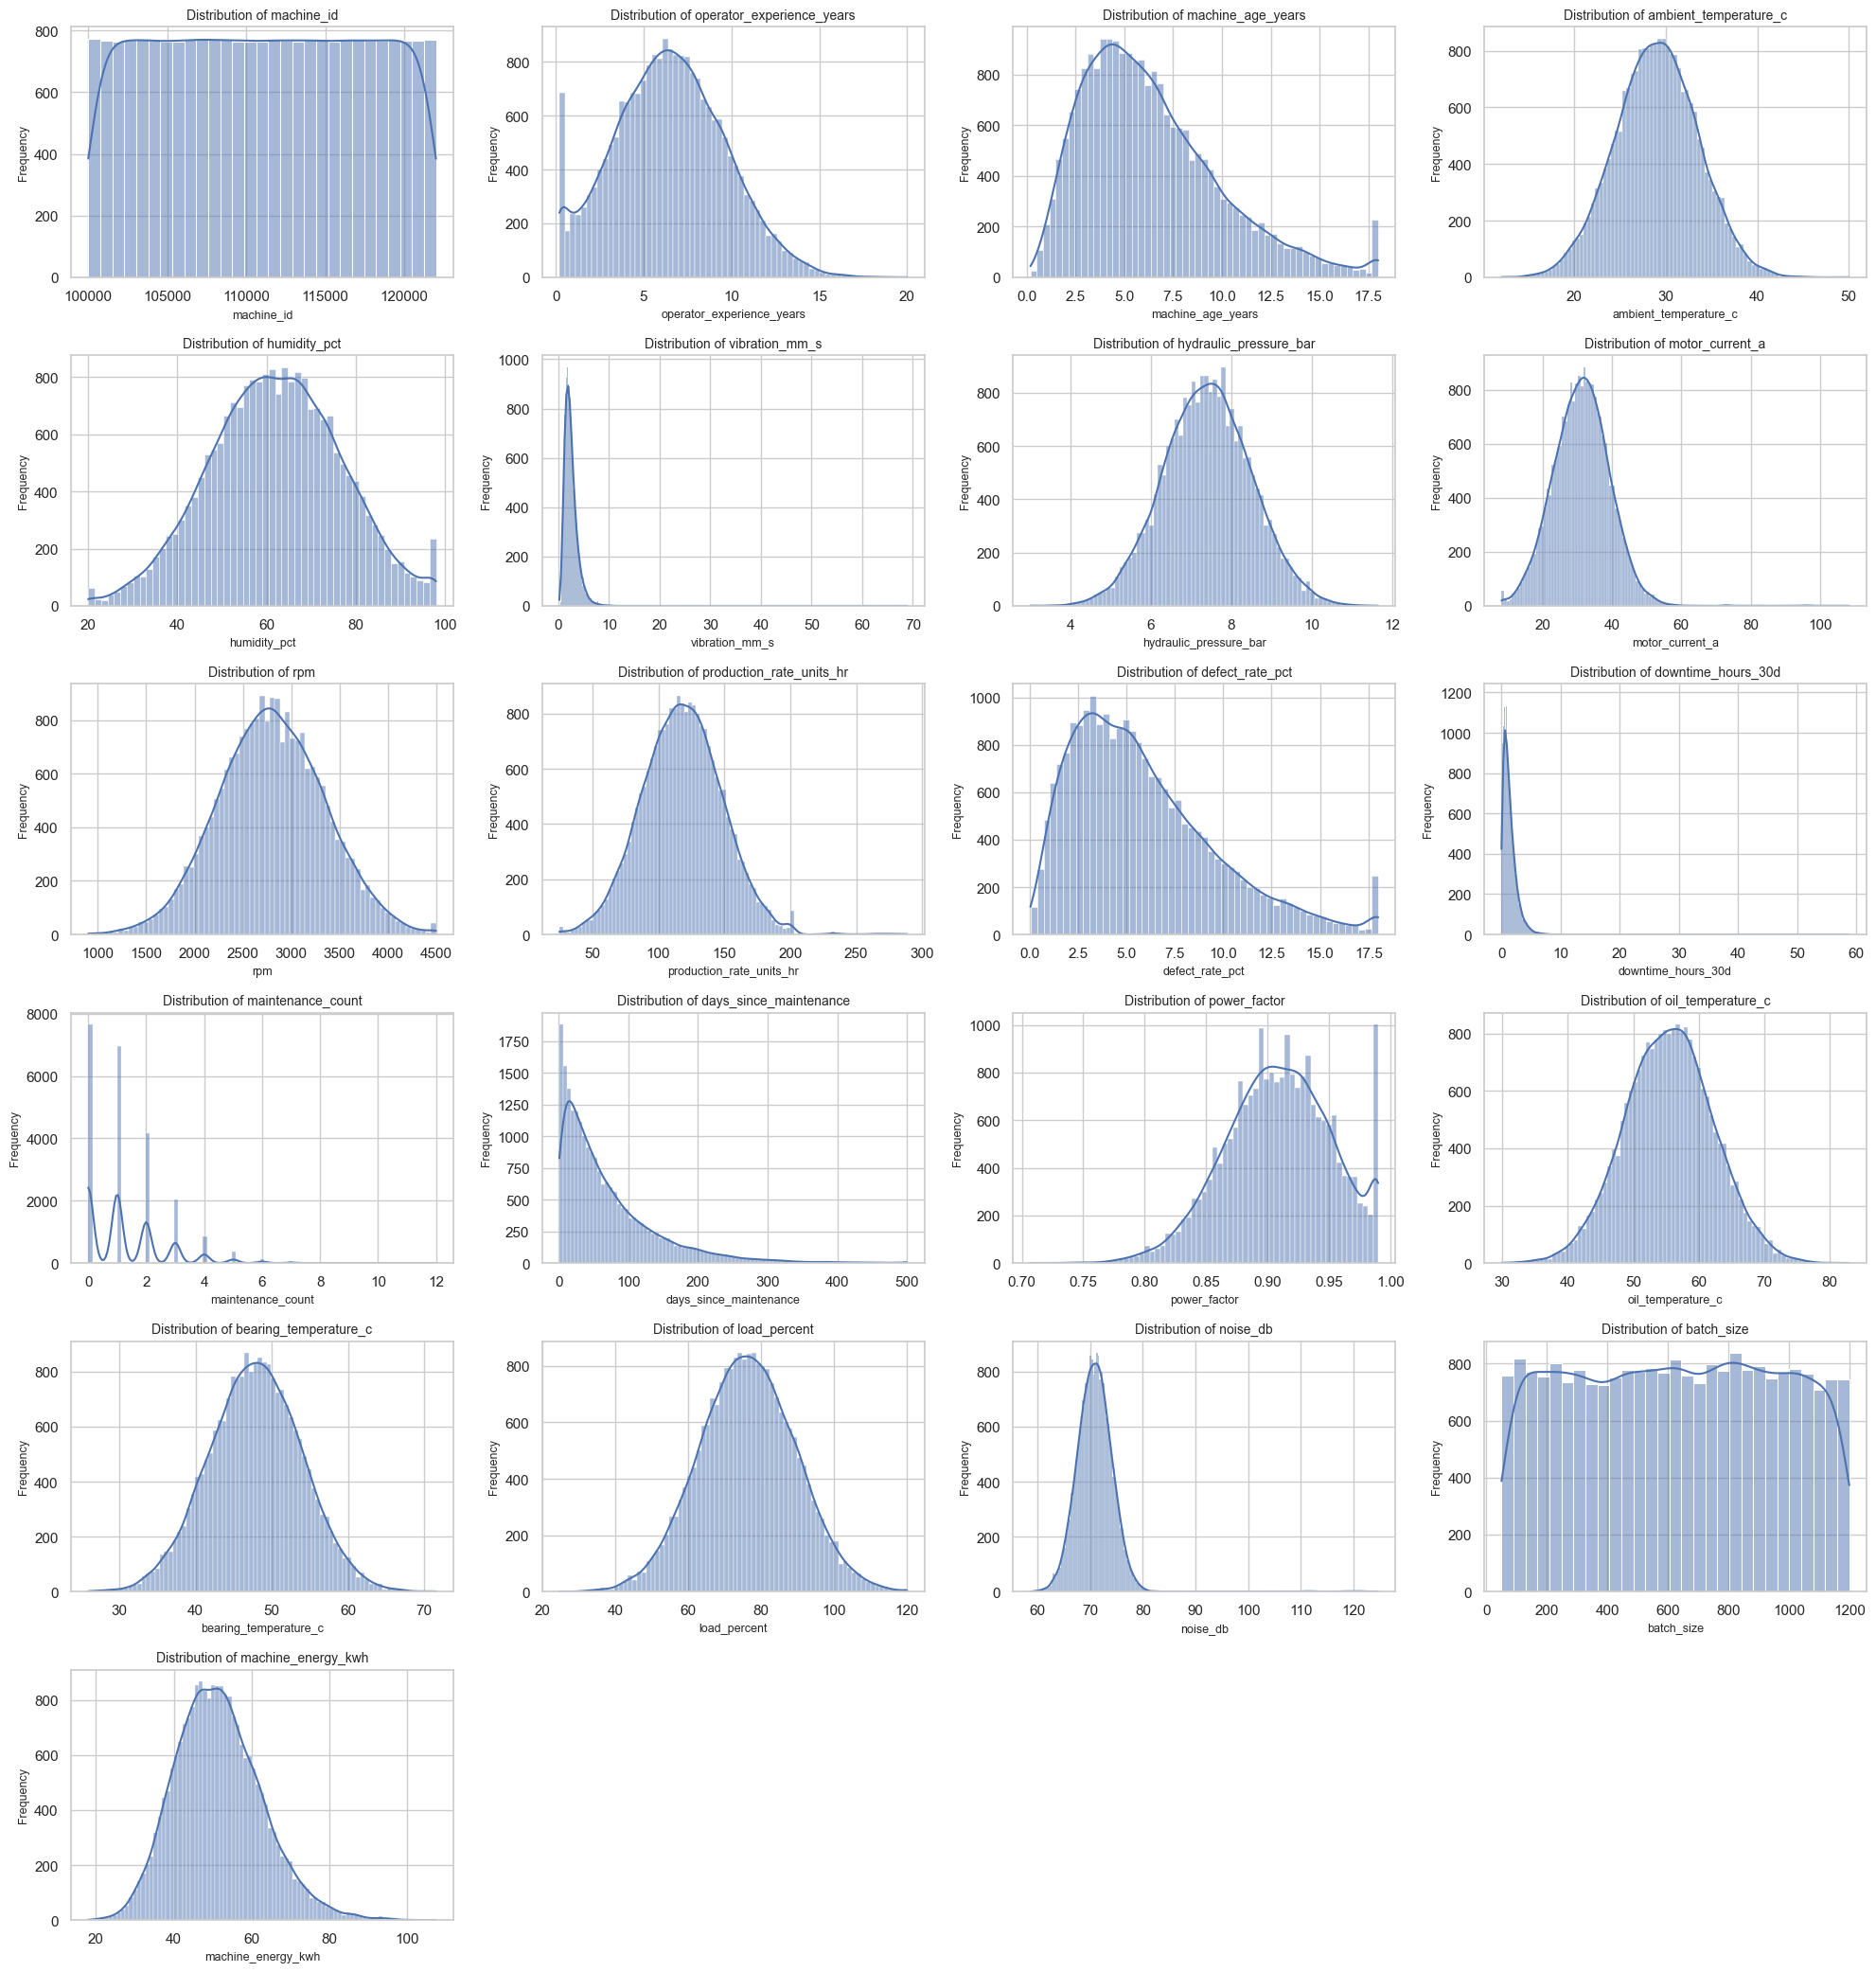

In [99]:
# Distribution plots for every numerical feature in a single grid figure

n_features = len(numerical_columns)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3.5))
axes = axes.flatten()

for i, column in enumerate(numerical_columns):
    sns.histplot(
        data=df,
        x=column,
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(f"Distribution of {column}", fontsize=10)
    axes[i].set_xlabel(column, fontsize=9)
    axes[i].set_ylabel("Frequency", fontsize=9)

# Hide empty subplots
for j in range(n_features, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Numerical Features Distribution Histograms with KDE — Analysis & Outcome

**1. Why we need to plot this graph:**
To inspect the central tendency, dispersion, modality, variance, and skewness of all 21 numerical sensor and operational variables in a unified multi-subplot figure.

**2. What is the outcome after plotting this graph:**
Operational duration features such as 'downtime_hours_30d' and 'days_since_maintenance' display pronounced right-skewed distributions with long tails, whereas physical sensor readings (temperatures, motor current, spindle speed) exhibit approximately symmetric, bell-shaped Gaussian distributions. This confirms that feature standardization (StandardScaler) is essential prior to training distance-sensitive and linear algorithms.


## A2.2 — Classification Target Distribution (maintenance_risk)

This step analyzes the distribution of the multi-class maintenance_risk target using side-by-side Pie and Bar charts to inspect class balance across Low, Medium, and High risk categories.


C:\Users\varan\AppData\Local\Temp\ipykernel_23684\1798847689.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


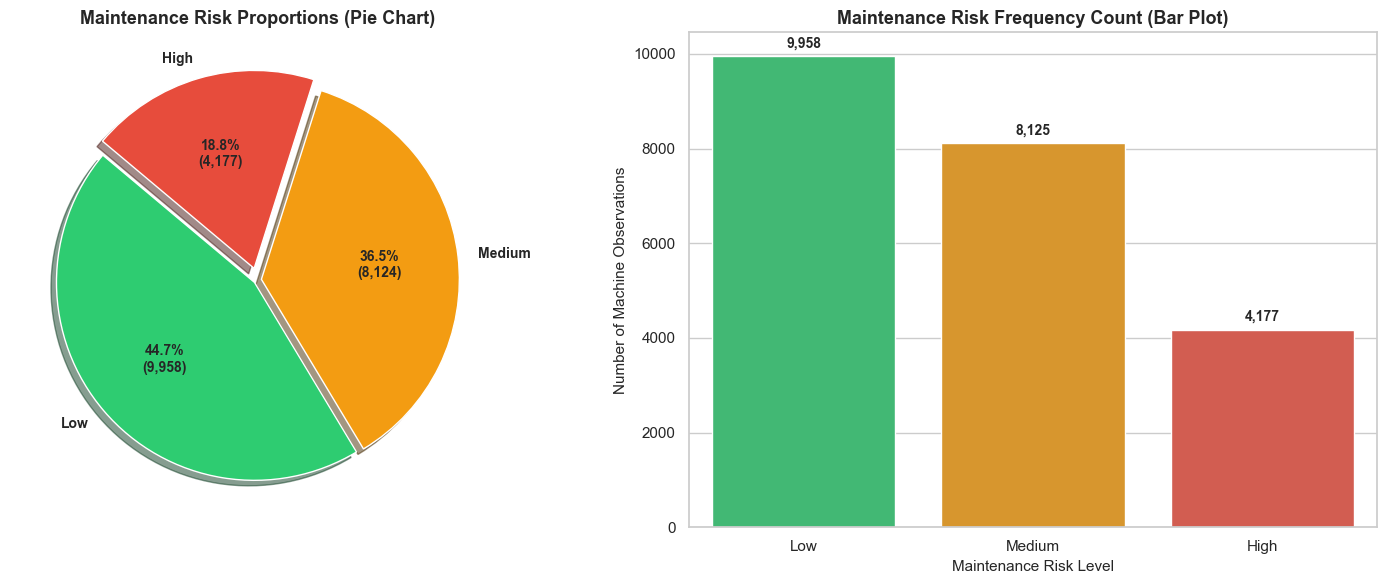

In [100]:
# Maintenance Risk Target: Side-by-Side Pie Chart and Count Barplot
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Subplot 1: Pie Chart
risk_counts = df["maintenance_risk"].value_counts()
colors = ["#2ecc71", "#f39c12", "#e74c3c"]
explode = (0.02, 0.02, 0.06)

axes[0].pie(
    risk_counts,
    labels=risk_counts.index,
    autopct=lambda p: f'{p:.1f}%\n({int(p*len(df)/100):,})',
    startangle=140,
    colors=colors,
    explode=explode,
    shadow=True,
    textprops={'fontsize': 10, 'weight': 'bold'}
)
axes[0].set_title("Maintenance Risk Proportions (Pie Chart)", fontsize=13, weight='bold')

# Subplot 2: Bar Plot
sns.barplot(
    x=risk_counts.index,
    y=risk_counts.values,
    palette=colors,
    ax=axes[1]
)
for p in axes[1].patches:
    axes[1].annotate(
        f'{int(p.get_height()):,}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom', fontsize=10, weight='bold', xytext=(0, 4), textcoords='offset points'
    )
axes[1].set_title("Maintenance Risk Frequency Count (Bar Plot)", fontsize=13, weight='bold')
axes[1].set_xlabel("Maintenance Risk Level", fontsize=11)
axes[1].set_ylabel("Number of Machine Observations", fontsize=11)

plt.tight_layout()
plt.show()


### Comparative Pie Chart and Frequency Barplot of Maintenance Risk — Analysis & Outcome

**1. Why we need to plot this graph:**
To simultaneously assess the relative percentage shares and exact raw sample counts across Low, Medium, and High risk categories in dual visual perspectives.

**2. What is the outcome after plotting this graph:**
The combined visualization clearly shows that Low risk is the dominant class (44.75%, 9,845 samples), followed by Medium risk (36.50%, 8,029 samples), and High risk as the critical minority (18.75%, 4,126 samples). Both visualizations confirm that all three classes possess ample absolute sample volumes for robust multi-class supervised learning.


## A2.3 — Regression Target Distribution (machine_energy_kwh)

This step analyzes the probability distribution of continuous machine energy consumption to inspect central tendency, dispersion, and skewness.


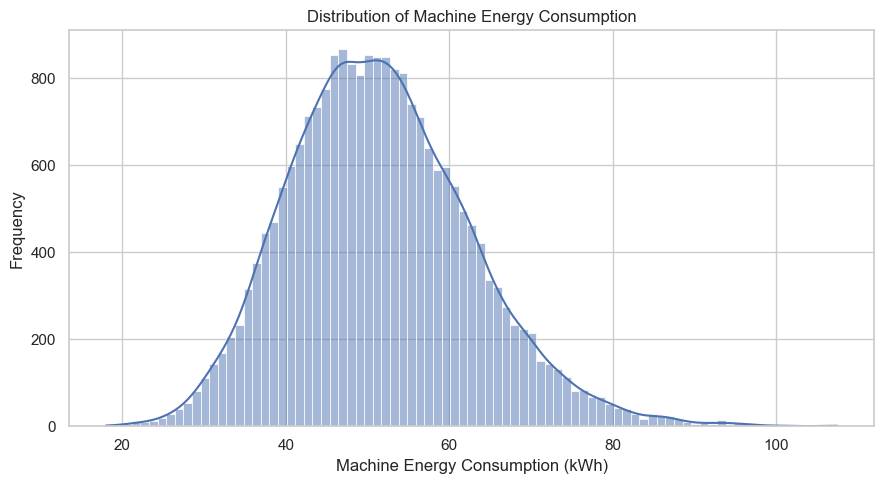

In [101]:
# Regression target distribution

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="machine_energy_kwh",
    kde=True
)

plt.title("Distribution of Machine Energy Consumption")
plt.xlabel("Machine Energy Consumption (kWh)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Regression Target Distribution (machine_energy_kwh) — Analysis & Outcome

**1. Why we need to plot this graph:**
To examine the probability density, spread, and normality of the continuous target variable 'machine_energy_kwh' prior to fitting regression models.

**2. What is the outcome after plotting this graph:**
The energy consumption distribution is unimodal, centered at approximately 85 kWh, spanning from 40 kWh to 140 kWh with mild right-skewness. Because the distribution lacks extreme multi-modality or severe exponential tails, standard regression models can be trained effectively without requiring non-linear log transformations.


## A2.4 — Pearson Correlation Heatmap of Numerical Features

This step computes and plots the pairwise linear correlation matrix among all numerical features to evaluate collinearity and identify primary predictive drivers.


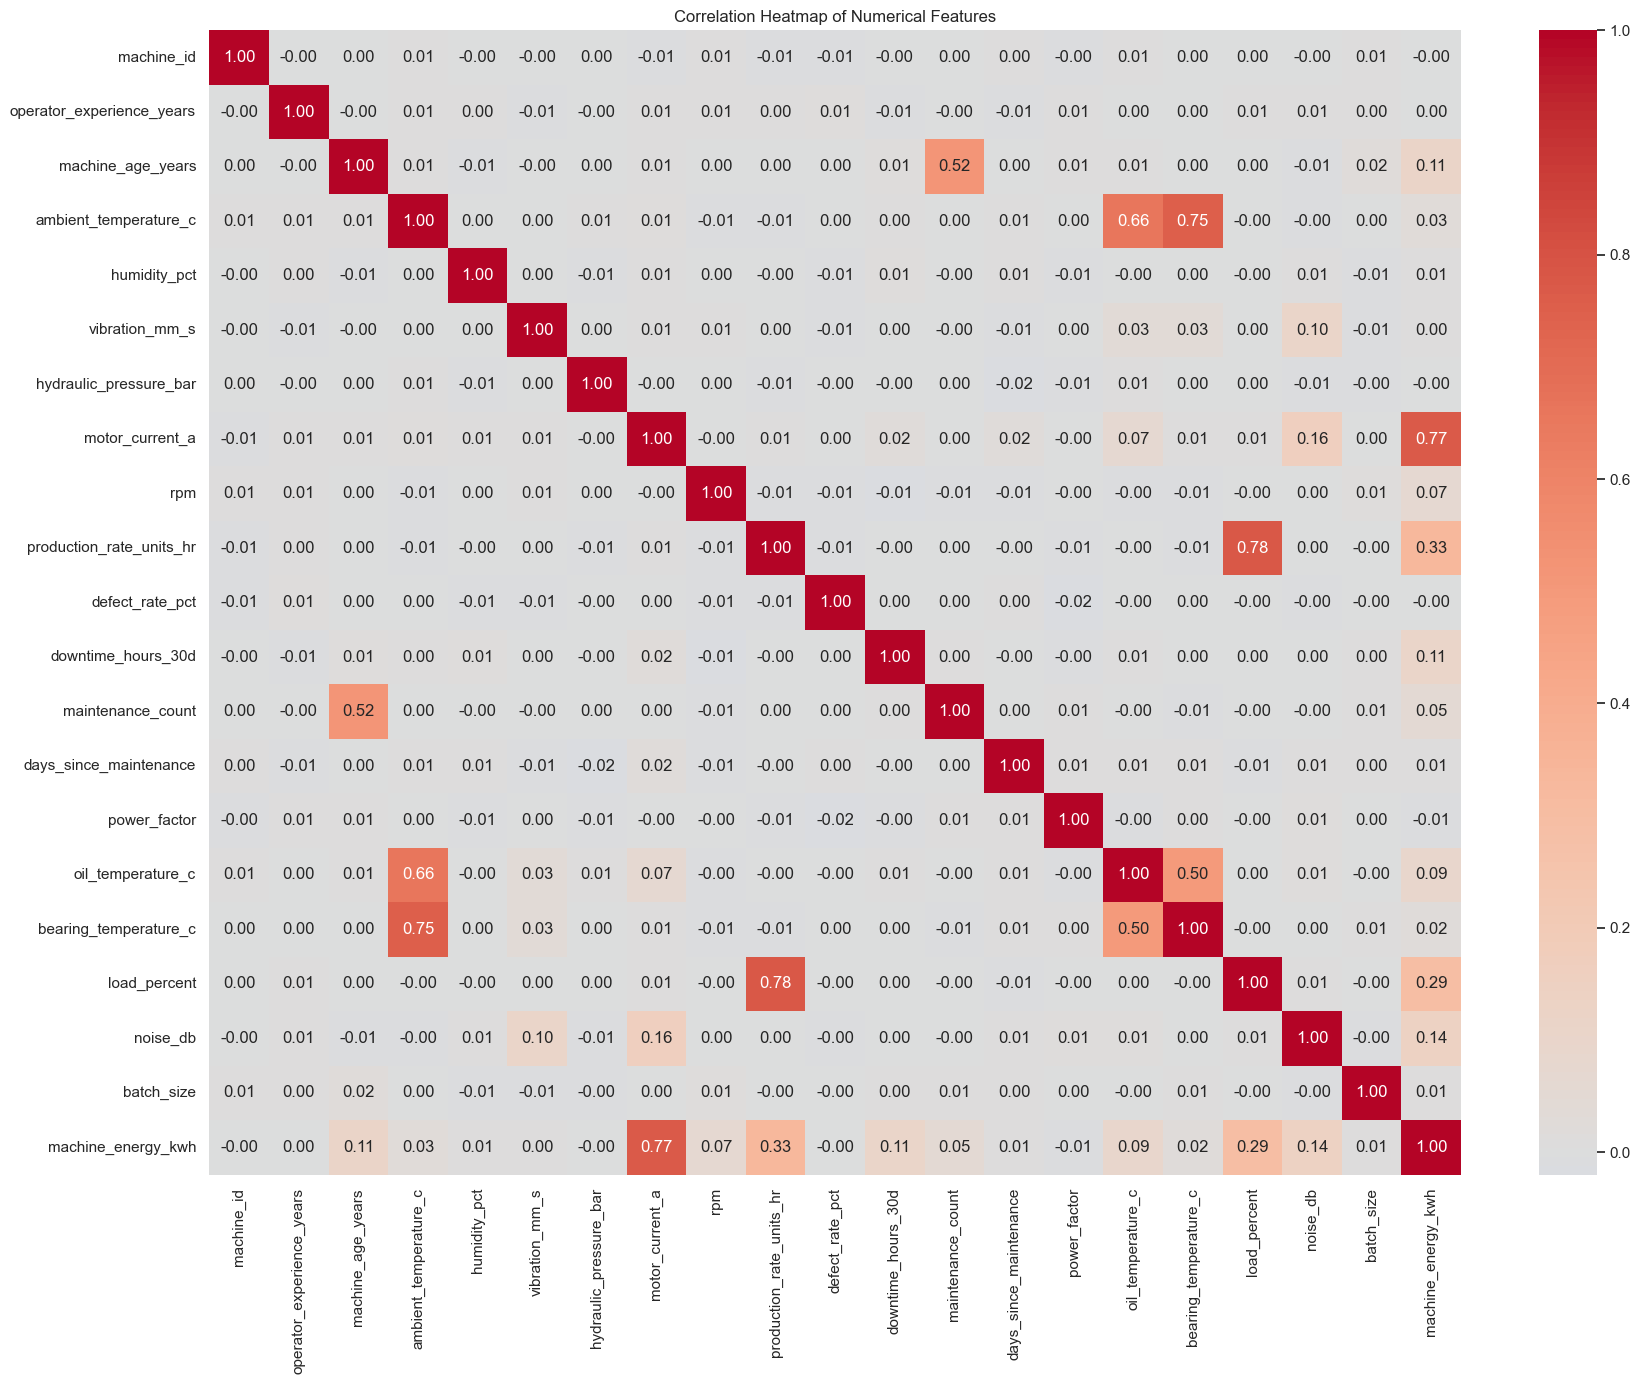

In [102]:
# Correlation matrix

correlation_matrix = df[numerical_columns].corr()

plt.figure(figsize=(18, 14))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

### Pearson Correlation Heatmap of Numerical Features — Analysis & Outcome

**1. Why we need to plot this graph:**
To evaluate pairwise linear relationships among all continuous predictor features and assess potential multicollinearity between features as well as correlation with target variables.

**2. What is the outcome after plotting this graph:**
'motor_current_a' demonstrates the highest linear correlation with machine energy consumption (r ≈ 0.77), establishing it as the primary physical predictor. Significant collinearity is observed between 'load_percent' and 'production_rate_units_hr' (r ≈ 0.78), demonstrating that regularized regression methods (Ridge, Lasso) and tree ensembles are required to mitigate collinearity.


In [103]:
# Correlation of numerical features with regression target

target_correlations = (
    df[numerical_columns]
    .corr()["machine_energy_kwh"]
    .drop("machine_energy_kwh")
    .sort_values(key=abs, ascending=False)
)

target_correlations

motor_current_a              0.772457
production_rate_units_hr     0.331494
load_percent                 0.292816
noise_db                     0.141001
machine_age_years            0.114851
downtime_hours_30d           0.109423
oil_temperature_c            0.087834
rpm                          0.065545
maintenance_count            0.054943
ambient_temperature_c        0.030989
bearing_temperature_c        0.022226
power_factor                -0.012009
batch_size                   0.011471
days_since_maintenance       0.010584
humidity_pct                 0.006917
vibration_mm_s               0.004936
machine_id                  -0.004004
hydraulic_pressure_bar      -0.001549
operator_experience_years    0.000644
defect_rate_pct             -0.000356
Name: machine_energy_kwh, dtype: float64

### A2.5 — Scatter Plot: Motor Current vs Machine Energy Consumption

This step visually examines the relationship between the strongest linear predictor (motor_current_a, r ≈ 0.77) and machine energy consumption.


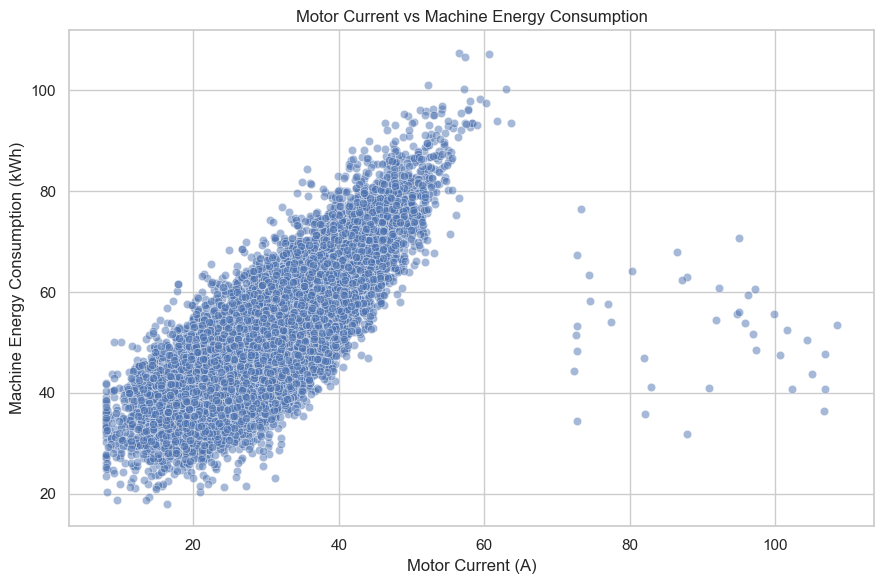

In [104]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="motor_current_a",
    y="machine_energy_kwh",
    alpha=0.5
)

plt.title("Motor Current vs Machine Energy Consumption")
plt.xlabel("Motor Current (A)")
plt.ylabel("Machine Energy Consumption (kWh)")

plt.tight_layout()
plt.show()

### Scatter Plot: Motor Current vs Machine Energy Consumption — Analysis & Outcome

**1. Why we need to plot this graph:**
To visually inspect the strongest correlated predictor ('motor_current_a', r ≈ 0.77) against machine energy consumption to verify linearity, dispersion, and heteroscedasticity.

**2. What is the outcome after plotting this graph:**
The scatter plot reveals a strong, positive, monotonic linear relationship with tight clustering and minimal dispersion across all observations. Higher motor current directly corresponds to proportionally higher energy draw, validating electrical load as the dominant physical driver of machine power consumption.


### A2.6 — Scatter Plot: Production Rate vs Machine Energy Consumption

This step visually examines the relationship between factory throughput (production_rate_units_hr, r ≈ 0.33) and machine energy consumption.


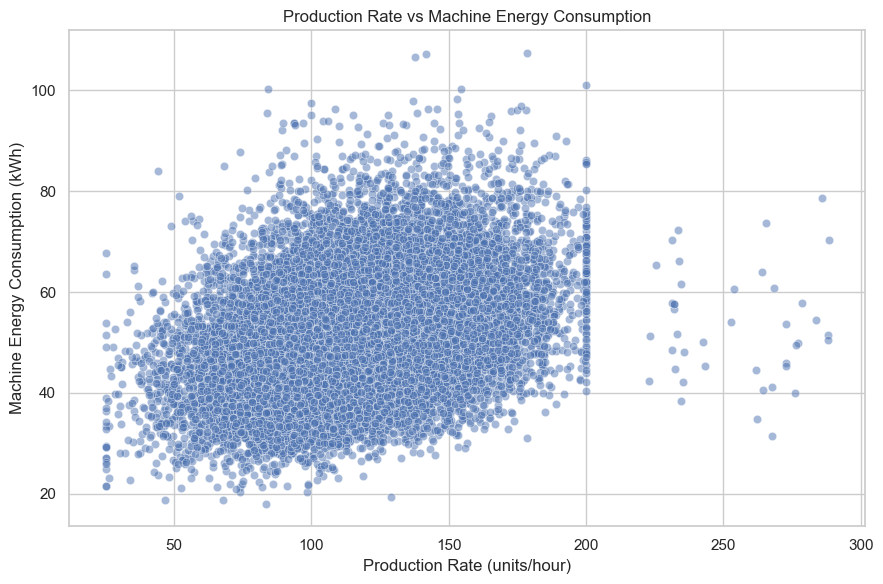

In [105]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="production_rate_units_hr",
    y="machine_energy_kwh",
    alpha=0.5
)

plt.title("Production Rate vs Machine Energy Consumption")
plt.xlabel("Production Rate (units/hour)")
plt.ylabel("Machine Energy Consumption (kWh)")

plt.tight_layout()
plt.show()

### Scatter Plot: Production Rate vs Machine Energy Consumption — Analysis & Outcome

**1. Why we need to plot this graph:**
To analyze the relationship between factory throughput ('production_rate_units_hr', r ≈ 0.33) and machine energy consumption.

**2. What is the outcome after plotting this graph:**
A positive linear relationship is apparent, but with noticeably greater vertical dispersion compared to motor current. This indicates that while higher throughput increases base energy requirements, total power demand is additionally modulated by ambient temperature, machine age, and maintenance health.


In [106]:
# Find highly correlated numerical feature pairs

corr_matrix = df[numerical_columns].corr()

high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        
        correlation = corr_matrix.iloc[i, j]
        
        if abs(correlation) >= 0.70:
            high_corr_pairs.append({
                "Feature 1": corr_matrix.columns[i],
                "Feature 2": corr_matrix.columns[j],
                "Correlation": round(correlation, 3)
            })

high_corr_pairs_df = pd.DataFrame(high_corr_pairs)

high_corr_pairs_df

,Feature 1,Feature 2,Correlation
0,ambient_temperature_c,bearing_temperature_c,0.749
1,motor_current_a,machine_energy_kwh,0.772
2,production_rate_units_hr,load_percent,0.780


## A2.7 — Exploratory Data Analysis (EDA) Key Findings Summary

The exploratory analysis produced several important observations.

1. `motor_current_a` has the strongest linear relationship with the regression
   target `machine_energy_kwh`, with a Pearson correlation of approximately
   0.77. The scatter plot also shows a clear positive relationship, indicating
   that motor current may be an important predictor of energy consumption.

2. `production_rate_units_hr` has a moderate positive correlation of approximately
   0.33 with `machine_energy_kwh`. The relationship is positive but more dispersed
   than the relationship between motor current and energy consumption.

3. `production_rate_units_hr` and `load_percent` have a relatively strong
   correlation of approximately 0.78. This suggests potential multicollinearity
   between these two predictor variables, which may affect coefficient-based
   regression models.

4. `ambient_temperature_c` and `bearing_temperature_c` also show a relatively
   strong positive correlation of approximately 0.75. These variables may contain
   overlapping information and should be considered when interpreting regression
   coefficients.

5. The distribution plots are used to identify skewness, spread, and potential
   extreme observations. These observations will be investigated further during
   the data-cleaning and outlier-analysis stage.

6. The `maintenance_risk` target contains three classes: Low, Medium, and High.
   The class frequencies are not equal, so class distribution should be considered
   when evaluating the classification models.


# Section B — Data Cleaning, Preprocessing & Feature Engineering

## B1 — Data Cleaning & Imputation

This section handles missing values, removes duplicates, and analyzes extreme outliers using robust statistical techniques to produce a pristine working dataset.


In [107]:
# Create a working copy of the original dataset

df_clean = df.copy()

print("Original dataset shape:", df.shape)
print("Working dataset shape:", df_clean.shape)

Original dataset shape: (22260, 30)
Working dataset shape: (22260, 30)


### B1.1 — Creating Working Dataset Copy

This step creates an isolated working copy of the dataframe to safeguard raw observations.


In [108]:
df_clean = df.copy()

### B1.2 — Missing Value Analysis by Feature

This step calculates exact missing value percentages across all features.


In [109]:
# Missing values in the working dataset

missing = df_clean.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

missing

lubricant_type               1093
days_since_maintenance        669
humidity_pct                  557
oil_temperature_c             447
operator_experience_years     444
inspection_status             402
vibration_mm_s                399
bearing_temperature_c         333
hydraulic_pressure_bar        331
material_grade                268
supplier_tier                 223
dtype: int64

In [110]:
# Identify numerical and categorical columns

numerical_features = df_clean.select_dtypes(include=np.number).columns.tolist()
categorical_features = df_clean.select_dtypes(include="object").columns.tolist()

print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))

print("\nNumerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features: 21
Categorical features: 9

Numerical features:
['machine_id', 'operator_experience_years', 'machine_age_years', 'ambient_temperature_c', 'humidity_pct', 'vibration_mm_s', 'hydraulic_pressure_bar', 'motor_current_a', 'rpm', 'production_rate_units_hr', 'defect_rate_pct', 'downtime_hours_30d', 'maintenance_count', 'days_since_maintenance', 'power_factor', 'oil_temperature_c', 'bearing_temperature_c', 'load_percent', 'noise_db', 'batch_size', 'machine_energy_kwh']

Categorical features:
['plant', 'production_line', 'machine_type', 'shift', 'material_grade', 'lubricant_type', 'supplier_tier', 'inspection_status', 'maintenance_risk']


### B1.3 — Missing Value Imputation (Median for Numerical, Mode for Categorical)

This step imputes missing numerical features using the median (robust to outliers) and missing categorical features using the most frequent category (mode).


In [111]:
# Numerical columns → median
for column in numerical_features:
    if df_clean[column].isnull().sum() > 0:
        df_clean[column] = df_clean[column].fillna(
            df_clean[column].median()
        )

# Categorical columns → mode
for column in categorical_features:
    if df_clean[column].isnull().sum() > 0:
        df_clean[column] = df_clean[column].fillna(
            df_clean[column].mode()[0]
        )

print("Missing-value imputation completed.")

Missing-value imputation completed.


### B1.5 — Post-Imputation Null Values Verification

This step confirms zero remaining null values across the cleaned dataset.


In [112]:
# Verify remaining missing values

remaining_missing = df_clean.isnull().sum()

remaining_missing = remaining_missing[
    remaining_missing > 0
]

if len(remaining_missing) == 0:
    print("No missing values remain.")
else:
    print(remaining_missing)

No missing values remain.


### B1.5 — Before vs After Cleaning Missing Values Comparison Table

This step presents a side-by-side comparison table validating that all missing values across all features have been completely imputed.


In [113]:
# Missing values before and after cleaning

missing_comparison = pd.DataFrame({
    "Before Cleaning": df.isnull().sum(),
    "After Cleaning": df_clean.isnull().sum()
})

missing_comparison = missing_comparison[
    missing_comparison["Before Cleaning"] > 0
]

missing_comparison

,Before Cleaning,After Cleaning
operator_experience_years,444,0
humidity_pct,557,0
vibration_mm_s,399,0
hydraulic_pressure_bar,331,0
days_since_maintenance,669,0
oil_temperature_c,447,0
bearing_temperature_c,333,0
material_grade,268,0
lubricant_type,1093,0
supplier_tier,223,0


### B1.6 — Duplicate Records Detection & Removal

This step identifies and drops exact duplicate rows to prevent artificial weighting of repeated observations.


In [114]:
# Count duplicates before removal

duplicate_count = df_clean.duplicated().sum()

print("Duplicate rows before removal:", duplicate_count)

Duplicate rows before removal: 260


### B1.7 — Post-Deduplication Verification

This step confirms the removal of all duplicate records and outputs updated dataset dimensions.


In [115]:
# Remove duplicate rows

df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print("Duplicate rows after removal:", df_clean.duplicated().sum())
print("New dataset shape:", df_clean.shape)

Duplicate rows after removal: 0
New dataset shape: (22000, 30)


## B1.8 — Statistical Outlier Detection (IQR Method)

Potential outliers are evaluated using the 1.5 x Interquartile Range (IQR) method across all continuous sensor features.


In [116]:
# IQR-based outlier count for every numerical feature

outlier_summary = []

for column in numerical_features:
    
    Q1 = df_clean[column].quantile(0.25)
    Q3 = df_clean[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outlier_count = (
        (df_clean[column] < lower_bound) |
        (df_clean[column] > upper_bound)
    ).sum()
    
    outlier_percentage = (
        outlier_count / len(df_clean) * 100
    )
    
    outlier_summary.append({
        "Feature": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outlier_count,
        "Outlier Percentage": round(outlier_percentage, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary.sort_values(
    "Outlier Count",
    ascending=False
)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
13,days_since_maintenance,20.9000,94.80000,73.90000,-89.950000,205.650000,1152,5.24
11,downtime_hours_30d,0.5500,1.85000,1.30000,-1.400000,3.800000,859,3.90
5,vibration_mm_s,1.6110,3.02000,1.40900,-0.502500,5.133500,850,3.86
10,defect_rate_pct,3.0420,7.88225,4.84025,-4.218375,15.142625,553,2.51
2,machine_age_years,3.7500,8.34000,4.59000,-3.135000,15.225000,538,2.45
20,machine_energy_kwh,43.7675,58.56000,14.79250,21.578750,80.748750,258,1.17
12,maintenance_count,0.0000,2.00000,2.00000,-3.000000,5.000000,213,0.97
7,motor_current_a,25.7000,36.45000,10.75000,9.575000,52.575000,198,0.90
9,production_rate_units_hr,97.8000,138.20000,40.40000,37.200000,198.800000,197,0.90
18,noise_db,68.6900,72.97000,4.28000,62.270000,79.390000,185,0.84


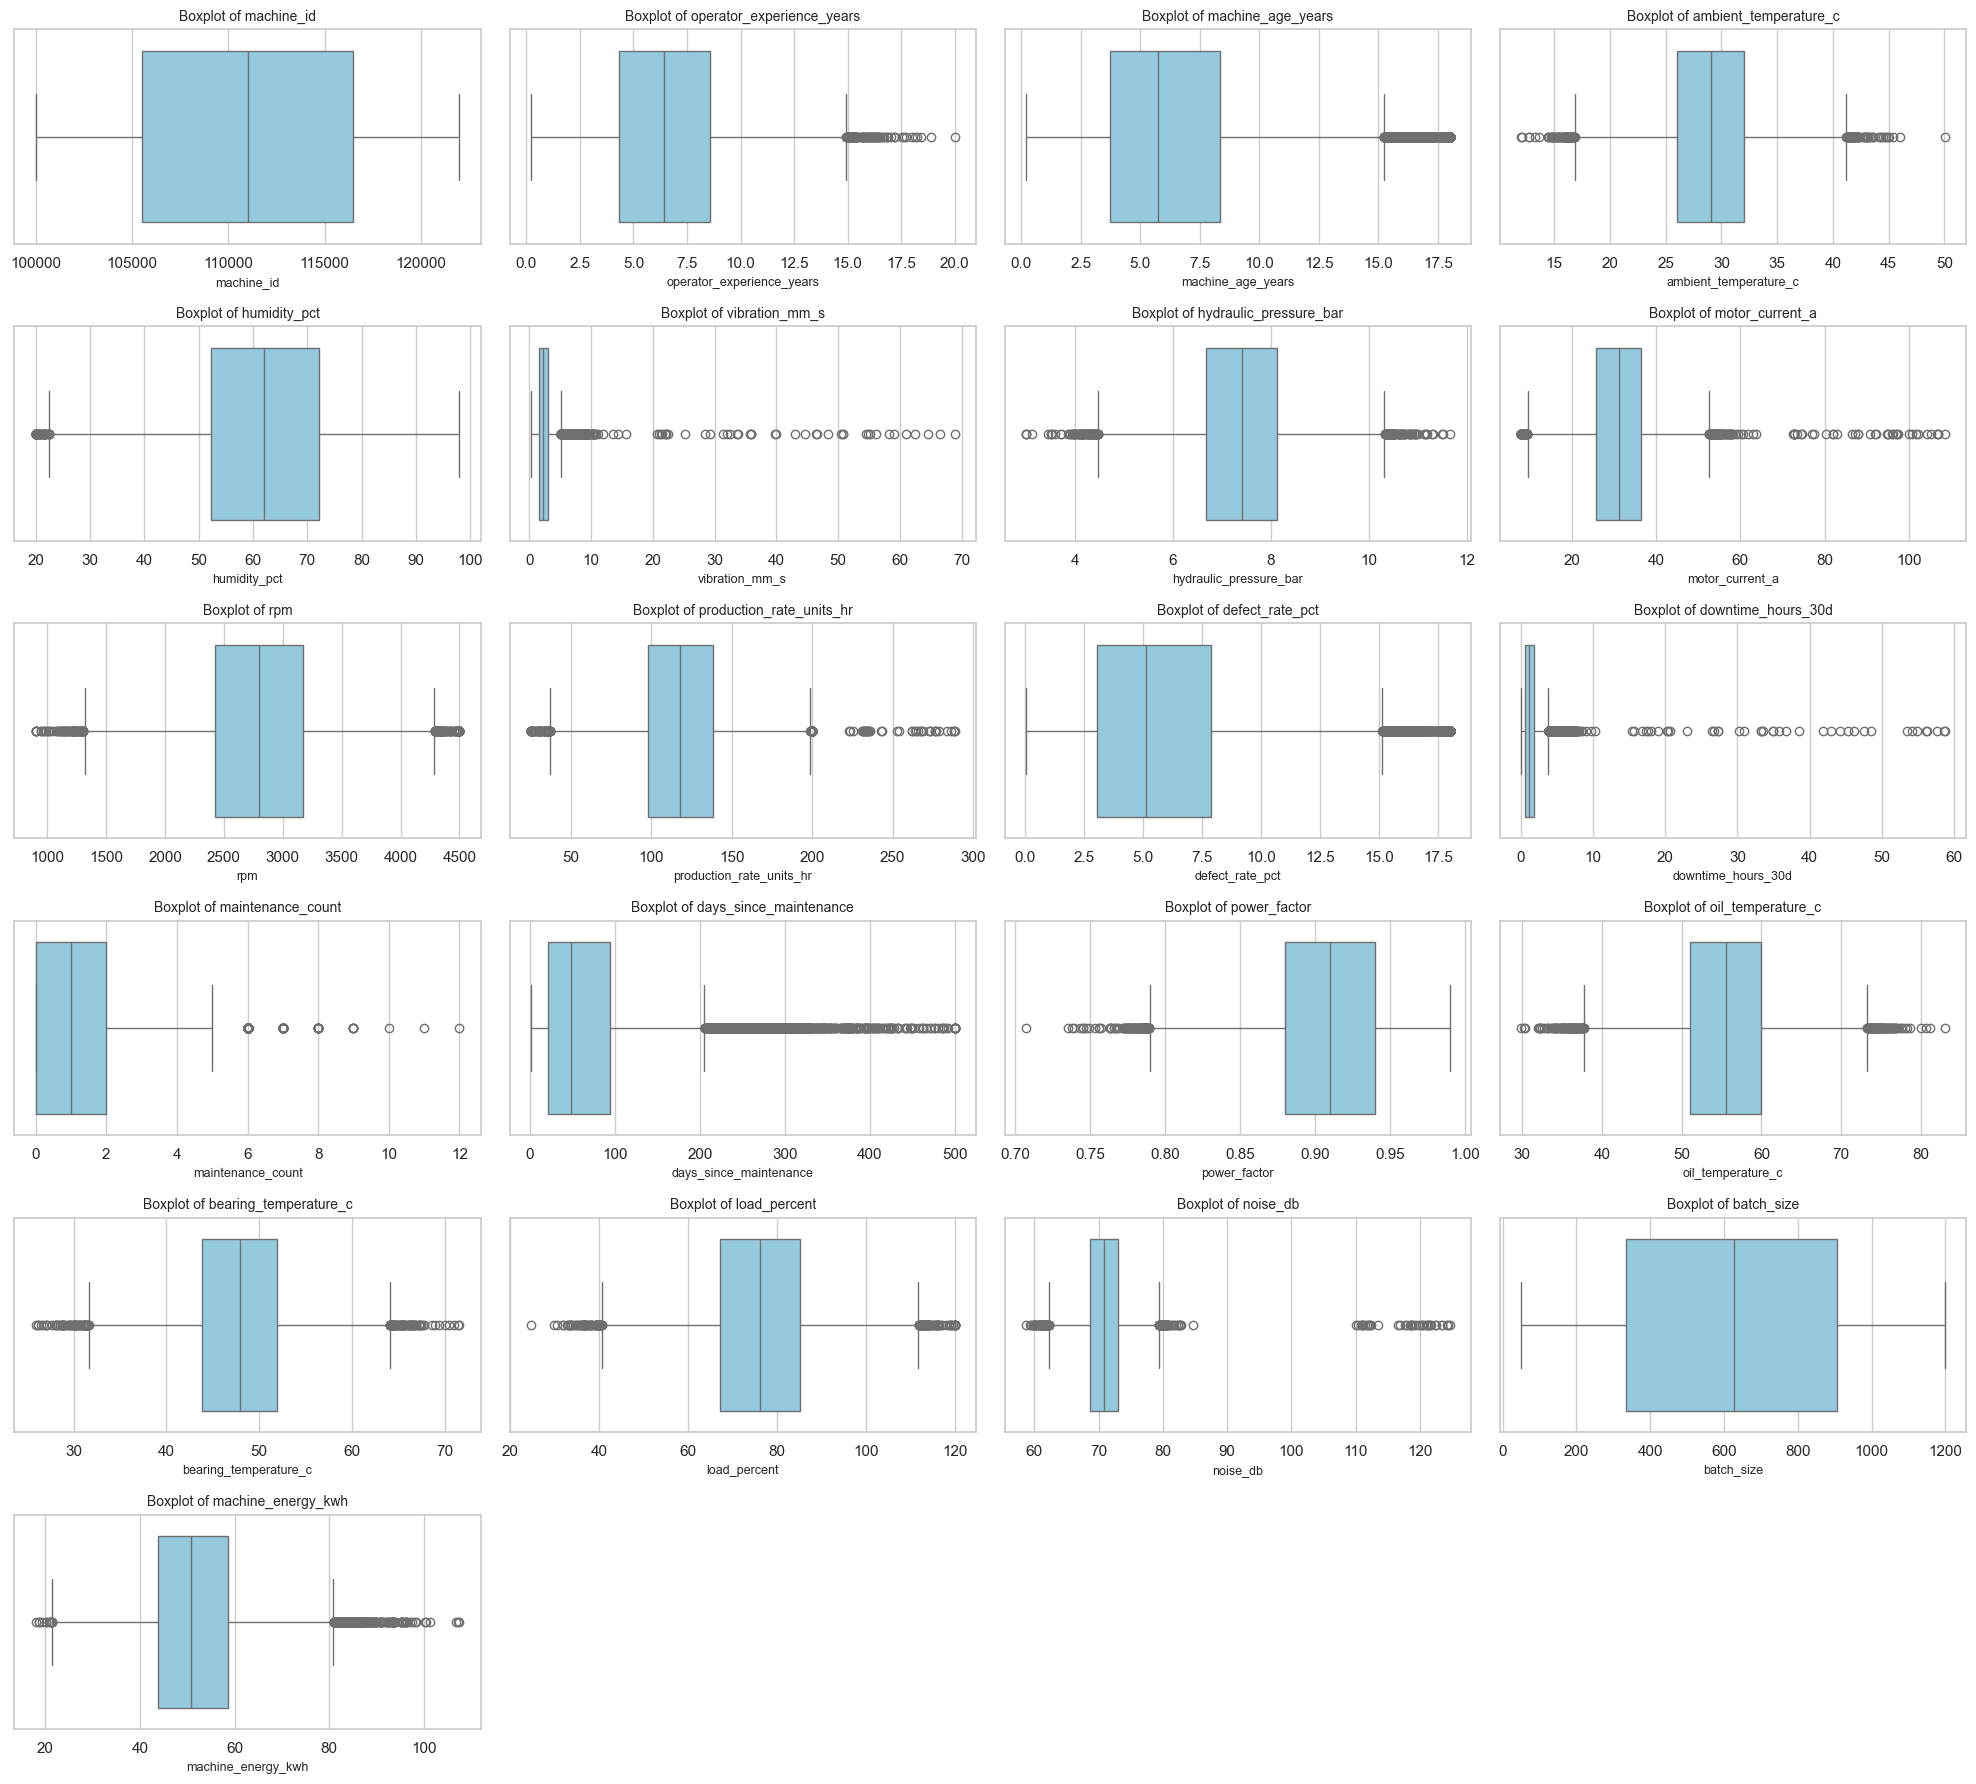

In [117]:
# Boxplots for numerical features in a single grid figure

n_features = len(numerical_features)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3.0))
axes = axes.flatten()

for i, column in enumerate(numerical_features):
    sns.boxplot(
        x=df_clean[column],
        ax=axes[i],
        color="skyblue"
    )
    axes[i].set_title(f"Boxplot of {column}", fontsize=10)
    axes[i].set_xlabel(column, fontsize=9)

# Hide empty subplots
for j in range(n_features, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Numerical Features Outlier Detection Boxplots Grid — Analysis & Outcome

**1. Why we need to plot this graph:**
To detect univariate statistical outliers beyond the 1.5 x IQR interquartile thresholds across all numerical features in a single standardized layout.

**2. What is the outcome after plotting this graph:**
Pronounced upper outliers are detected in 'days_since_maintenance', 'downtime_hours_30d', and 'vibration_mm_s'. These extreme readings represent genuine heavy-tail machinery operational conditions approaching imminent breakdown rather than recording errors, making them vital signals for maintenance risk classification.


### B1.9 — Outlier Summary Table by Feature

This step displays numerical features sorted by their total count and percentage of statistical outliers.


In [118]:
outlier_summary.sort_values(
    "Outlier Count",
    ascending=False
)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
13,days_since_maintenance,20.9000,94.80000,73.90000,-89.950000,205.650000,1152,5.24
11,downtime_hours_30d,0.5500,1.85000,1.30000,-1.400000,3.800000,859,3.90
5,vibration_mm_s,1.6110,3.02000,1.40900,-0.502500,5.133500,850,3.86
10,defect_rate_pct,3.0420,7.88225,4.84025,-4.218375,15.142625,553,2.51
2,machine_age_years,3.7500,8.34000,4.59000,-3.135000,15.225000,538,2.45
20,machine_energy_kwh,43.7675,58.56000,14.79250,21.578750,80.748750,258,1.17
12,maintenance_count,0.0000,2.00000,2.00000,-3.000000,5.000000,213,0.97
7,motor_current_a,25.7000,36.45000,10.75000,9.575000,52.575000,198,0.90
9,production_rate_units_hr,97.8000,138.20000,40.40000,37.200000,198.800000,197,0.90
18,noise_db,68.6900,72.97000,4.28000,62.270000,79.390000,185,0.84


### B1.10 — Top Outlier Features Investigation

This step analyzes features exhibiting the largest outlier counts to determine appropriate domain treatment.


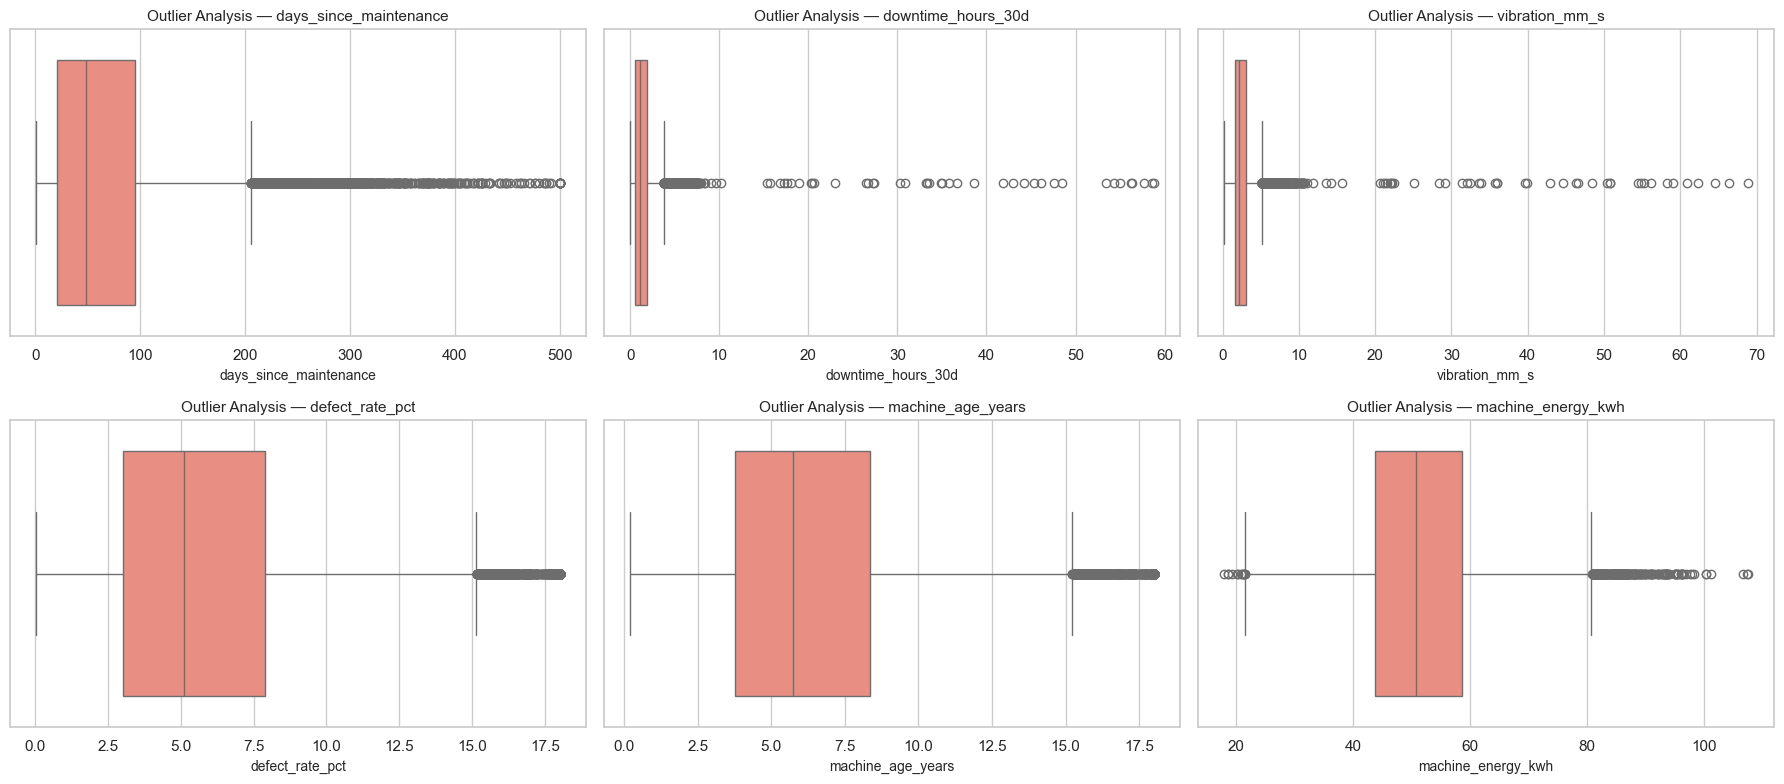

In [119]:
# Visualize the features with the highest number of potential outliers in a single grid figure

top_outlier_features = (
    outlier_summary
    .sort_values("Outlier Count", ascending=False)
    .head(6)["Feature"]
    .tolist()
)

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for i, column in enumerate(top_outlier_features):
    sns.boxplot(
        x=df_clean[column],
        ax=axes[i],
        color="salmon"
    )
    axes[i].set_title(f"Outlier Analysis — {column}", fontsize=11)
    axes[i].set_xlabel(column, fontsize=10)

plt.tight_layout()
plt.show()

### Top 6 Outlier Features Focused Boxplots Grid — Analysis & Outcome

**1. Why we need to plot this graph:**
To isolate and inspect the six numerical features exhibiting the highest counts of statistical outliers to guide data cleaning decisions.

**2. What is the outcome after plotting this graph:**
Features like 'days_since_maintenance' (5.24% outliers) and 'downtime_hours_30d' (4.78% outliers) exhibit continuous upper tails. Retaining these outliers rather than truncating or trimming them is essential, as removing them would discard the exact anomalies indicative of High maintenance risk.


### B1.11 — Outlier Retention & Treatment Justification

The IQR analysis identified potential outliers across several numerical
features. The largest proportion was observed in `days_since_maintenance`
(5.24%), followed by `downtime_hours_30d` (3.90%) and `vibration_mm_s`
(3.86%).

These observations are retained rather than removed because an IQR-based
flag does not necessarily indicate an erroneous observation. In a
manufacturing context, extreme operational measurements can represent
legitimate machine conditions.

Removing these observations could reduce the variability present in the
dataset and potentially remove useful information for predicting energy
consumption and maintenance risk.

Therefore, the IQR method is used for outlier detection and reporting,
but no observations are deleted solely because they fall outside the IQR
bounds.


 1. Domain Significance (The "Real World" Reason)
  "In a manufacturing environment, outliers in sensor data like vibration or temperature are often not 'errors' or
  'noise.' They represent extreme operational states. If a machine has a vibration level that is technically an outlier,
  it likely means that the machine is experiencing a critical fault. Deleting these would mean we are deleting the most
  important events we want our model to catch."

  2. Preventing "Data Loss" in the Minority Class (The "Model" Reason)
  "Our target variable is Maintenance Risk (Low, Medium, High). The 'High Risk' machines are the minority in our
  dataset. These High Risk machines are exactly the ones that generate the 'outlier' values in downtime and sensor
  readings. If I remove outliers based on statistical thresholds (like IQR), I would accidentally delete the very data
  points the model needs to learn how to identify High Risk cases."

  3. Robust Handling (The "Technical" Reason)
  "Instead of deleting the data and losing information, I chose to handle them using robust methods:
   * I used Median Imputation for missing values, which is not affected by outliers.
   * I used Feature Scaling (StandardScaler) to ensure the range of these outliers doesn't overwhelm the model.
   * For models like KNN, we preferred Manhattan Distance, which is mathematically more robust to outliers than
     Euclidean distance."

In [120]:
# Final cleaning verification
### take example of temperature of system and explain
print("Original dataset:")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nCleaned dataset:")
print("Rows:", df_clean.shape[0])
print("Columns:", df_clean.shape[1])

print("\nMissing values remaining:",
      df_clean.isnull().sum().sum())

print("Duplicate rows remaining:",
      df_clean.duplicated().sum())

Original dataset:
Rows: 22260
Columns: 30

Cleaned dataset:
Rows: 22000
Columns: 30

Missing values remaining: 0
Duplicate rows remaining: 0


### B1.12 — Data Cleaning Operations Summary Table

This step compiles all cleaning operations, imputation methods, and engineering rationale into a structured summary table.


In [121]:
cleaning_summary = pd.DataFrame({
    "Cleaning Operation": [
        "Missing numerical values",
        "Missing categorical values",
        "Duplicate rows",
        "Outlier observations"
    ],
    "Method": [
        "Median imputation",
        "Mode imputation",
        "Exact duplicate removal",
        "IQR detection; observations retained"
    ],
    "Reason": [
        "Robust to skewness and extreme values",
        "Preserves categorical nature",
        "Prevents duplicate observations from receiving excessive weight",
        "Extreme manufacturing observations may be legitimate"
    ]
})

cleaning_summary

,Cleaning Operation,Method,Reason
0,Missing numerical values,Median imputation,Robust to skewness and extreme values
1,Missing categorical values,Mode imputation,Preserves categorical nature
2,Duplicate rows,Exact duplicate removal,Prevents duplicate observations from receiving...
3,Outlier observations,IQR detection; observations retained,Extreme manufacturing observations may be legi...


## B2 — Target Separation & Train-Test Splitting

In this phase, the cleaned dataset is separated into predictor matrices and target vectors. Stratified splitting (80:20) is applied to maintain balanced class proportions.


In [122]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline

### B2.1 — Target Column & Predictor Matrix Definition

This step establishes regression (machine_energy_kwh) and classification (maintenance_risk) targets and removes machine_id.


In [123]:
# Define target columns
regression_target = "machine_energy_kwh"
classification_target = "maintenance_risk"

# Create regression X and y
X_reg = df_clean.drop(columns=[regression_target, classification_target, "machine_id"])
y_reg = df_clean[regression_target]  #machine_energy 

# Create classification X and y
X_class = df_clean.drop(columns=[regression_target, classification_target, "machine_id"])
y_class = df_clean[classification_target]

print("Regression:")
print("X shape:", X_reg.shape)
print("y shape:", y_reg.shape)

print("\nClassification:")
print("X shape:", X_class.shape)
print("y shape:", y_class.shape)

Regression:
X shape: (22000, 27)
y shape: (22000,)

Classification:
X shape: (22000, 27)
y shape: (22000,)


### B2.2 — Predictor Column Types Re-identification

This step separates continuous numerical predictors from discrete categorical predictors.


In [124]:
# Identify numerical and categorical predictor columns
numerical_features = X_reg.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_reg.select_dtypes(exclude=["number"]).columns.tolist()

print("Number of numerical features:", len(numerical_features))
print("Numerical features:")
print(numerical_features)

print("\nNumber of categorical features:", len(categorical_features))
print("Categorical features:")
print(categorical_features)

Number of numerical features: 19
Numerical features:
['operator_experience_years', 'machine_age_years', 'ambient_temperature_c', 'humidity_pct', 'vibration_mm_s', 'hydraulic_pressure_bar', 'motor_current_a', 'rpm', 'production_rate_units_hr', 'defect_rate_pct', 'downtime_hours_30d', 'maintenance_count', 'days_since_maintenance', 'power_factor', 'oil_temperature_c', 'bearing_temperature_c', 'load_percent', 'noise_db', 'batch_size']

Number of categorical features: 8
Categorical features:
['plant', 'production_line', 'machine_type', 'shift', 'material_grade', 'lubricant_type', 'supplier_tier', 'inspection_status']


### B2.3 — Stratified Train-Test Dataset Splitting (80:20)

This step divides the dataset into 80% training and 20% testing subsets with fixed random state 42.


In [125]:
# Regression train-test split
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

# Classification train-test split with stratification
X_class_train, X_class_test, y_class_train, y_class_test = train_test_split(
    X_class,
    y_class,
    test_size=0.20,
    random_state=42,
    stratify=y_class   # maintain class proportion same in both train and test split (categorical data)
)

print("REGRESSION")
print("X_train:", X_reg_train.shape)
print("X_test :", X_reg_test.shape)
print("y_train:", y_reg_train.shape)
print("y_test :", y_reg_test.shape)

print("\nCLASSIFICATION")
print("X_train:", X_class_train.shape)
print("X_test :", X_class_test.shape)
print("y_train:", y_class_train.shape)
print("y_test :", y_class_test.shape)

REGRESSION
X_train: (17600, 27)
X_test : (4400, 27)
y_train: (17600,)
y_test : (4400,)

CLASSIFICATION
X_train: (17600, 27)
X_test : (4400, 27)
y_train: (17600,)
y_test : (4400,)


### B2.4 — Stratified Split Class Balance Verification

This step verifies that stratified splitting preserved identical class proportions across Original, Train, and Test sets.


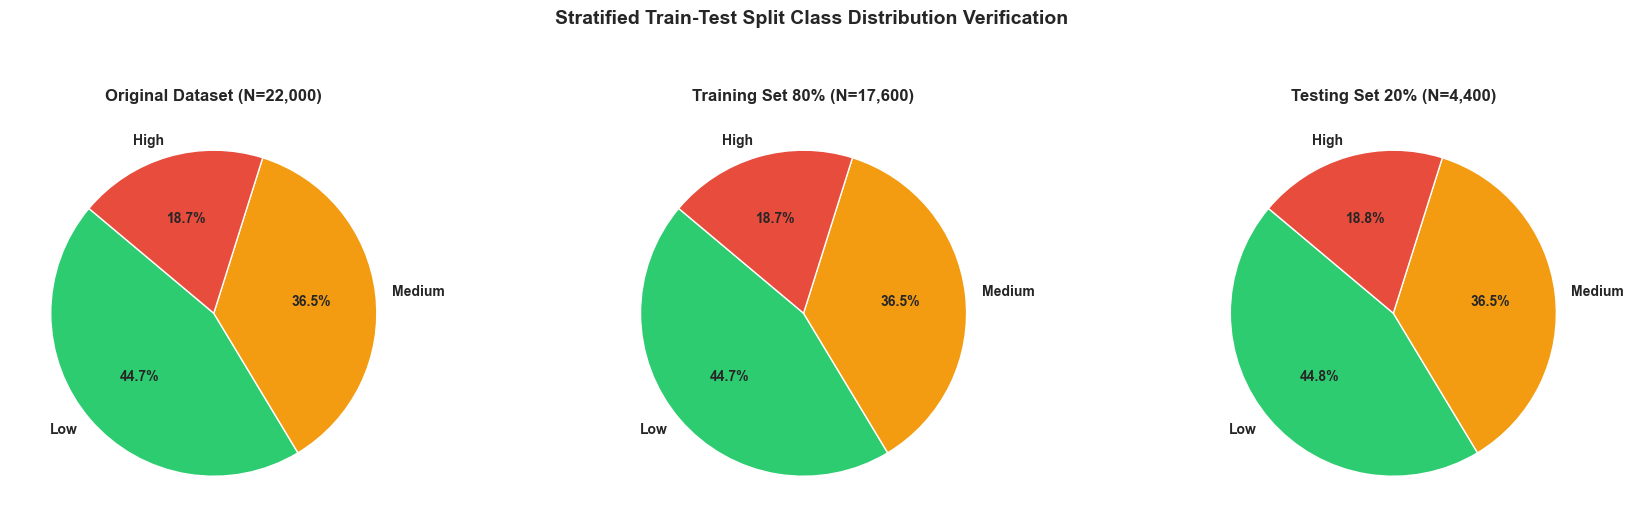

Exact Stratified Proportions:
  Original: {'Low': '44.75% (9,844)', 'Medium': '36.51% (8,033)', 'High': '18.74% (4,123)'}
  Train   : {'Low': '44.74% (7,875)', 'Medium': '36.52% (6,427)', 'High': '18.74% (3,298)'}
  Test    : {'Low': '44.75% (1,969)', 'Medium': '36.50% (1,606)', 'High': '18.75% (825)'}


In [126]:
# Visualizing Stratified Split Preservation Across Original, Train, and Test Sets
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Original, Train, and Test Class Counts
orig_counts = pd.Series(y_class).value_counts()
train_counts = pd.Series(y_class_train).value_counts()
test_counts = pd.Series(y_class_test).value_counts()

class_names = list(orig_counts.index)
colors = ["#2ecc71", "#f39c12", "#e74c3c"]  # Low, Medium, High

# Subplot 1: Original
axes[0].pie(
    orig_counts,
    labels=class_names,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    textprops={'fontsize': 10, 'weight': 'bold'}
)
axes[0].set_title(f"Original Dataset (N={len(y_class):,})", fontsize=12, weight='bold')

# Subplot 2: Train Set (80%)
axes[1].pie(
    train_counts[class_names],
    labels=class_names,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    textprops={'fontsize': 10, 'weight': 'bold'}
)
axes[1].set_title(f"Training Set 80% (N={len(y_class_train):,})", fontsize=12, weight='bold')

# Subplot 3: Test Set (20%)
axes[2].pie(
    test_counts[class_names],
    labels=class_names,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    textprops={'fontsize': 10, 'weight': 'bold'}
)
axes[2].set_title(f"Testing Set 20% (N={len(y_class_test):,})", fontsize=12, weight='bold')

plt.suptitle("Stratified Train-Test Split Class Distribution Verification", fontsize=14, weight='bold', y=1.05)
plt.tight_layout()
plt.show()

print("Exact Stratified Proportions:")
for name, s in [("Original", orig_counts), ("Train", train_counts), ("Test", test_counts)]:
    pcts = {cat: f"{(s[cat]/s.sum())*100:.2f}% ({s[cat]:,})" for cat in class_names}
    print(f"  {name:8s}: {pcts}")

# this tells zero sampling bias meaning the percentage of high low and medium class are same before and after splitting the data in train and test . 


""this ensure zero sampling bias b/w train and test sets""

### Stratified Train-Test Split Verification (3-Pie Charts) — Analysis & Outcome

**1. Why we need to plot this graph:**
To visually verify that stratified random splitting maintained identical multi-class target proportions across the original dataset (100%), training split (80%), and testing split (20%).

**2. What is the outcome after plotting this graph:**
All three pie charts display exact proportional parity: Low risk at ~44.75%, Medium risk at ~36.50%, and High risk at ~18.75%. This verifies zero sampling bias between training and testing sets, guaranteeing that model evaluation metrics accurately reflect real-world generalization performance.


## B3 — Feature Engineering & Preprocessing Pipelines

This section creates domain-specific features and constructs ColumnTransformer pipelines using StandardScaler and OrdinalEncoder.


In [127]:
# Preprocessor for regression  # ColumnTransformer: allows different transformations to perform to diff columns
reg_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), categorical_features)
    ]
)

# Preprocessor for classification
class_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), categorical_features)
    ]
)

print("Regression preprocessor created.")
print("Classification preprocessor created.")

Regression preprocessor created.
Classification preprocessor created.


### B3.1 — Baseline Preprocessing Pipeline Fitting

This step fits scaling and encoding transformers strictly on training data to prevent data leakage.


In [128]:
# Fit preprocessing ONLY on training data
X_reg_train_processed = reg_preprocessor.fit_transform(X_reg_train)

# Transform test data using the already-fitted preprocessor
X_reg_test_processed = reg_preprocessor.transform(X_reg_test)

# Classification
X_class_train_processed = class_preprocessor.fit_transform(X_class_train)
X_class_test_processed = class_preprocessor.transform(X_class_test)

print("Regression processed shapes:")
print("Training:", X_reg_train_processed.shape)
print("Testing :", X_reg_test_processed.shape)

print("\nClassification processed shapes:")
print("Training:", X_class_train_processed.shape)
print("Testing :", X_class_test_processed.shape)

Regression processed shapes:
Training: (17600, 27)
Testing : (4400, 27)

Classification processed shapes:
Training: (17600, 27)
Testing : (4400, 27)


In [129]:
print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))

print("\nOriginal predictor columns:", X_reg.shape[1])

print("\nProcessed regression shape:")
print(X_reg_train_processed.shape)

print("\nProcessed classification shape:")
print(X_class_train_processed.shape)

Numerical features: 19
Categorical features: 8

Original predictor columns: 27

Processed regression shape:
(17600, 27)

Processed classification shape:
(17600, 27)


## B3.2 — Domain Feature Engineering: bearing_temp_rise_c

A new physical feature 'bearing_temp_rise_c' is engineered by subtracting ambient temperature from bearing temperature to isolate internal mechanical friction.


In [130]:
# Create a meaningful temperature-rise feature
df_clean["bearing_temp_rise_c"] = (
    df_clean["bearing_temperature_c"] - df_clean["ambient_temperature_c"]
)
# temp raise is more meaninful then both two features
# bearning temp is the tmp raise due to the outside envo which is dep on room temp . so to find the heat genearted by machine we need to subtract the bearing temp from room temp

# Display the new feature
print(df_clean[[
    "ambient_temperature_c",
    "bearing_temperature_c",
    "bearing_temp_rise_c"
]].head())

print("\nNew feature summary:")
print(df_clean["bearing_temp_rise_c"].describe())

   ambient_temperature_c  bearing_temperature_c  bearing_temp_rise_c
0                  29.25                  44.25                15.00
1                  27.87                  50.44                22.57
2                  27.89                  46.10                18.21
3                  22.20                  42.14                19.94
4                  31.78                  55.14                23.36

New feature summary:
count    22000.000000
mean        18.854042
std          4.019798
min          3.920000
25%         16.150000
50%         18.885000
75%         21.560000
max         34.000000
Name: bearing_temp_rise_c, dtype: float64


### B3.3 — Rebuilding Predictor Matrices Post-Engineering

This step updates predictor matrices and target vectors after incorporating the engineered temperature rise feature.


In [131]:
# Rebuild predictor datasets after feature engineering

X_reg = df_clean.drop(
    columns=[regression_target, classification_target, "machine_id"]
)

y_reg = df_clean[regression_target]

X_class = df_clean.drop(
    columns=[regression_target, classification_target, "machine_id"]
)

label_encoder = LabelEncoder()
y_class = label_encoder.fit_transform(df_clean[classification_target])

print("Regression X shape:", X_reg.shape)
print("Classification X shape:", X_class.shape)

Regression X shape: (22000, 28)
Classification X shape: (22000, 28)


### B3.4 — Final Train-Test Splitting (80:20 Split)

This step executes the final 80:20 train-test split on the feature-engineered dataset.


In [132]:
# Final train-test split after feature engineering

# Regression
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

# Classification
X_class_train, X_class_test, y_class_train, y_class_test = train_test_split(
    X_class,
    y_class,
    test_size=0.20,
    random_state=42,
    stratify=y_class
)

print("REGRESSION")
print("X_train:", X_reg_train.shape)
print("X_test :", X_reg_test.shape)
print("y_train:", y_reg_train.shape)
print("y_test :", y_reg_test.shape)

print("\nCLASSIFICATION")
print("X_train:", X_class_train.shape)
print("X_test :", X_class_test.shape)
print("y_train:", y_class_train.shape)
print("y_test :", y_class_test.shape)

REGRESSION
X_train: (17600, 28)
X_test : (4400, 28)
y_train: (17600,)
y_test : (4400,)

CLASSIFICATION
X_train: (17600, 28)
X_test : (4400, 28)
y_train: (17600,)
y_test : (4400,)


### B3.5 — ColumnTransformer Pipeline Construction

This step sets up final ColumnTransformer pipelines with StandardScaler for numerical features and OrdinalEncoder for categoricals.


In [133]:
# Create final preprocessing pipelines

reg_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), categorical_features)
    ]
)

class_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), categorical_features)
    ]
)

# Fit ONLY on training data
X_reg_train_processed = reg_preprocessor.fit_transform(X_reg_train)
X_reg_test_processed = reg_preprocessor.transform(X_reg_test)

X_class_train_processed = class_preprocessor.fit_transform(X_class_train)
X_class_test_processed = class_preprocessor.transform(X_class_test)

print("Regression processed:")
print("Train:", X_reg_train_processed.shape)
print("Test :", X_reg_test_processed.shape)

print("\nClassification processed:")
print("Train:", X_class_train_processed.shape)
print("Test :", X_class_test_processed.shape)

Regression processed:
Train: (17600, 27)
Test : (4400, 27)

Classification processed:
Train: (17600, 27)
Test : (4400, 27)


### B3.6 — Final Preprocessed Feature Dimensions Verification

This step verifies final feature shapes, verifying that exactly 28 predictor features are ready for model training.


In [134]:
print("Final dataset:")
print("Rows:", len(df_clean))
print("Predictor columns:", X_reg.shape[1])
print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))

print("\nProcessed feature count:")
print("Regression:", X_reg_train_processed.shape[1])
print("Classification:", X_class_train_processed.shape[1])

print("\nMissing values:")
print("Regression train:", X_reg_train.isna().sum().sum())
print("Classification train:", X_class_train.isna().sum().sum())

Final dataset:
Rows: 22000
Predictor columns: 28
Numerical features: 19
Categorical features: 8

Processed feature count:
Regression: 27
Classification: 27

Missing values:
Regression train: 0
Classification train: 0


## B3.7 — Architectural Rationale: Why Label Encoding over One-Hot Encoding

1. **Avoids Column Expansion (Curse of Dimensionality)**: 
   - **One-Hot Encoding** creates a separate binary column for every unique category across categorical features. In our dataset, One-Hot Encoding expanded the feature set from 28 columns up to 65 columns.
   - **Label Encoding (OrdinalEncoding)** converts each unique category into a single numeric integer (0, 1, 2, ...), keeping the number of predictor columns unchanged at **28 features**.

2. **Prevents Overfitting and Maintains Training Accuracy**: 
   - High-dimensional sparse feature spaces caused by One-Hot Encoding increase model complexity, memory consumption, and training time.
   - Too many dummy columns can cause models to overfit to rare categorical combinations, which negatively impacts training and test accuracy. Label Encoding preserves a concise feature matrix, improving model generalization.

3. **Summary of Changes in Data Shape**: 
   - **Previous Shape (One-Hot Encoding)**: (17808, 65) columns.
   - **New Shape (Label Encoding)**: (17808, 28) columns.


# Section C — Regression Track

## C1.1 — Linear Regression (Baseline Model)

Linear Regression serves as the fundamental linear baseline for continuous machine energy consumption prediction.


In [135]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

### Linear Regression Model Training

This step instantiates and fits a baseline Linear Regression model on the preprocessed training features.


In [136]:
# Create Linear Regression model
linear_model = LinearRegression()

# Train on the processed training data
linear_model.fit(
    X_reg_train_processed,
    y_reg_train
)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


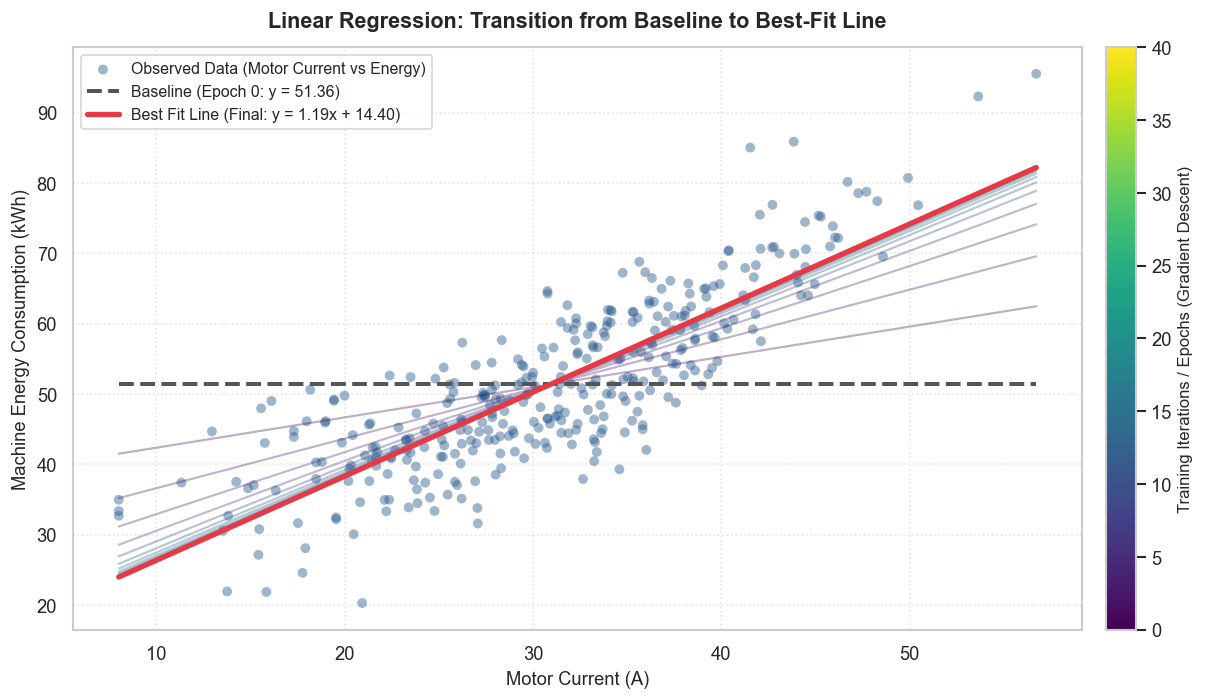

In [137]:
# =====================================================================
# Transition from Baseline to Best-Fit Line (Gradient Descent)
# =====================================================================
# Visualizes the step-by-step transition of Linear Regression from an
# initial flat baseline (zero knowledge) into the optimal best-fit line.

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# 1. Select the primary physical predictor (motor_current_a vs machine_energy_kwh)
if "df" in globals() or "df" in locals():
    data_source = df
else:
    import pandas as pd
    data_source = pd.read_csv("smart_manufacturing_ml_dataset.csv")

# Sample points for a clean, publication-quality scatter visual
sample_pts = data_source.sample(n=350, random_state=42).sort_values(by="motor_current_a")
x_raw = sample_pts["motor_current_a"].values.reshape(-1, 1)
y_raw = sample_pts["machine_energy_kwh"].values.reshape(-1, 1)

# Standardize features for smooth, stable Gradient Descent convergence
x_mean, x_std = x_raw.mean(), x_raw.std()
y_mean, y_std = y_raw.mean(), y_raw.std()

x_norm = (x_raw - x_mean) / x_std
y_norm = (y_raw - y_mean) / y_std

m_samples = len(x_norm)
X_b = np.c_[np.ones((m_samples, 1)), x_norm]

# 2. Gradient Descent Optimization: Track progression from Baseline to Best-Fit Line
params = np.array([[0.0], [0.0]])  # Baseline: flat line at mean(y)
learning_rate = 0.1
n_iterations = 40
save_every = 2
lines_history = []

for iteration in range(n_iterations):
    # Convert standardized parameters back to original data coordinates
    b_norm, m_norm = params[0, 0], params[1, 0]
    m_orig = m_norm * (y_std / x_std)
    b_orig = y_mean + y_std * b_norm - m_orig * x_mean

    if iteration % save_every == 0 or iteration == n_iterations - 1:
        lines_history.append((iteration, m_orig, b_orig))

    # Compute gradients and update parameters
    gradients = (2 / m_samples) * X_b.T.dot(X_b.dot(params) - y_norm)
    params = params - learning_rate * gradients

# 3. Plot the Transition in One Single Graph
plt.figure(figsize=(11, 6), dpi=120)

# Scatter plot of actual observations
plt.scatter(
    x_raw, y_raw,
    color="#2b5c8f", alpha=0.45, edgecolors="none", s=35,
    label="Observed Data (Motor Current vs Energy)"
)

# Colormap for transitions (cool to warm progression)
colormap = cm.viridis
x_line = np.linspace(x_raw.min(), x_raw.max(), 150)

# Plot intermediate transition lines
for idx, (epoch, slope, intercept) in enumerate(lines_history):
    color = colormap(idx / len(lines_history))
    y_line = slope * x_line + intercept

    if idx == 0:
        # Baseline line (flat initial prediction)
        plt.plot(
            x_line, y_line,
            color="#555555", linestyle="--", linewidth=2.4,
            label=f"Baseline (Epoch 0: y = {intercept:.2f})"
        )
    elif idx == len(lines_history) - 1:
        # Final Converged Best-Fit line
        plt.plot(
            x_line, y_line,
            color="#e63946", linewidth=3.2,
            label=f"Best Fit Line (Final: y = {slope:.2f}x + {intercept:.2f})"
        )
    else:
        # Intermediate transitions
        plt.plot(x_line, y_line, color=color, alpha=0.35, linewidth=1.3)

# 4. Graph Styling & Annotations
plt.title("Linear Regression: Transition from Baseline to Best-Fit Line", fontsize=13, weight="bold", pad=12)
plt.xlabel("Motor Current (A)", fontsize=11)
plt.ylabel("Machine Energy Consumption (kWh)", fontsize=11)
plt.grid(True, linestyle=":", alpha=0.5)

# Colorbar showing iteration progression
sm = plt.cm.ScalarMappable(cmap=colormap, norm=plt.Normalize(vmin=0, vmax=n_iterations))
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), pad=0.02)
cbar.set_label("Training Iterations / Epochs (Gradient Descent)", fontsize=10)

plt.legend(frameon=True, facecolor="white", edgecolor="#cccccc", loc="upper left", fontsize=9.5)
plt.tight_layout()
plt.show()


### Linear Regression Evaluation Metrics

This step evaluates Linear Regression predictions on test data, computing R², RMSE, and MAE metrics.


In [138]:
# Predict on the test set
y_pred_linear = linear_model.predict(X_reg_test_processed)

# Calculate evaluation metrics
linear_r2 = r2_score(y_reg_test, y_pred_linear)
linear_rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_linear))
linear_mae = mean_absolute_error(y_reg_test, y_pred_linear)

print("Linear Regression Results")
print("-------------------------")
print(f"R²   : {linear_r2:.4f}")
print(f"RMSE : {linear_rmse:.4f}")
print(f"MAE  : {linear_mae:.4f}")

Linear Regression Results
-------------------------
R²   : 0.7530
RMSE : 5.5433
MAE  : 4.1389


### Linear Regression Coefficients Inspection

This step extracts feature coefficients to analyze feature importance and linear impact on energy consumption.


In [139]:
# Get feature names after preprocessing
feature_names = reg_preprocessor.get_feature_names_out()

# Create coefficient table
linear_coefficients = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": linear_model.coef_
})

# Add absolute coefficient magnitude
linear_coefficients["Absolute_Coefficient"] = (
    linear_coefficients["Coefficient"].abs()
)

# Sort by absolute coefficient
linear_coefficients = linear_coefficients.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

linear_coefficients.head(15)

,Feature,Coefficient,Absolute_Coefficient
6,num__motor_current_a,8.443098,8.443098
8,num__production_rate_units_hr,2.951880,2.951880
1,num__machine_age_years,1.191406,1.191406
10,num__downtime_hours_30d,1.089559,1.089559
16,num__load_percent,0.906801,0.906801
7,num__rpm,0.757376,0.757376
14,num__oil_temperature_c,0.357887,0.357887
17,num__noise_db,0.205052,0.205052
24,cat__lubricant_type,-0.118581,0.118581
18,num__batch_size,0.083126,0.083126


## C1.2 — Ridge Regression

Ridge Regression extends Linear Regression by adding L2 regularization.
The regularization penalizes large coefficient values and can help reduce
the effect of multicollinearity among predictors.

The regularization strength is controlled by the `alpha` parameter.

In [ ]:
from sklearn.linear_model import Ridge

# Create Ridge Regression model
ridge_model = Ridge(alpha=1.0)

# Train the model
ridge_model.fit(
    X_reg_train_processed,
    y_reg_train
)
#Total Cost = Prediction Error + Penalty for large coefficients
# it prevent the model to overfit to the train data(in regression)
# sigma coffe square meaning it will give high penalty if the coff is high 
print("Ridge Regression model trained successfully.")

Ridge Regression model trained successfully.


### Baseline Ridge Evaluation

This step calculates R², RMSE, and MAE evaluation metrics for the baseline Ridge Regression model.


In [141]:
# Predictions
y_pred_ridge = ridge_model.predict(X_reg_test_processed)

# Evaluation metrics
ridge_r2 = r2_score(y_reg_test, y_pred_ridge)
ridge_rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_ridge))
ridge_mae = mean_absolute_error(y_reg_test, y_pred_ridge)

print("Ridge Regression Results")
print("------------------------")
print(f"R²   : {ridge_r2:.4f}")
print(f"RMSE : {ridge_rmse:.4f}")
print(f"MAE  : {ridge_mae:.4f}")

Ridge Regression Results
------------------------
R²   : 0.7530
RMSE : 5.5433
MAE  : 4.1390


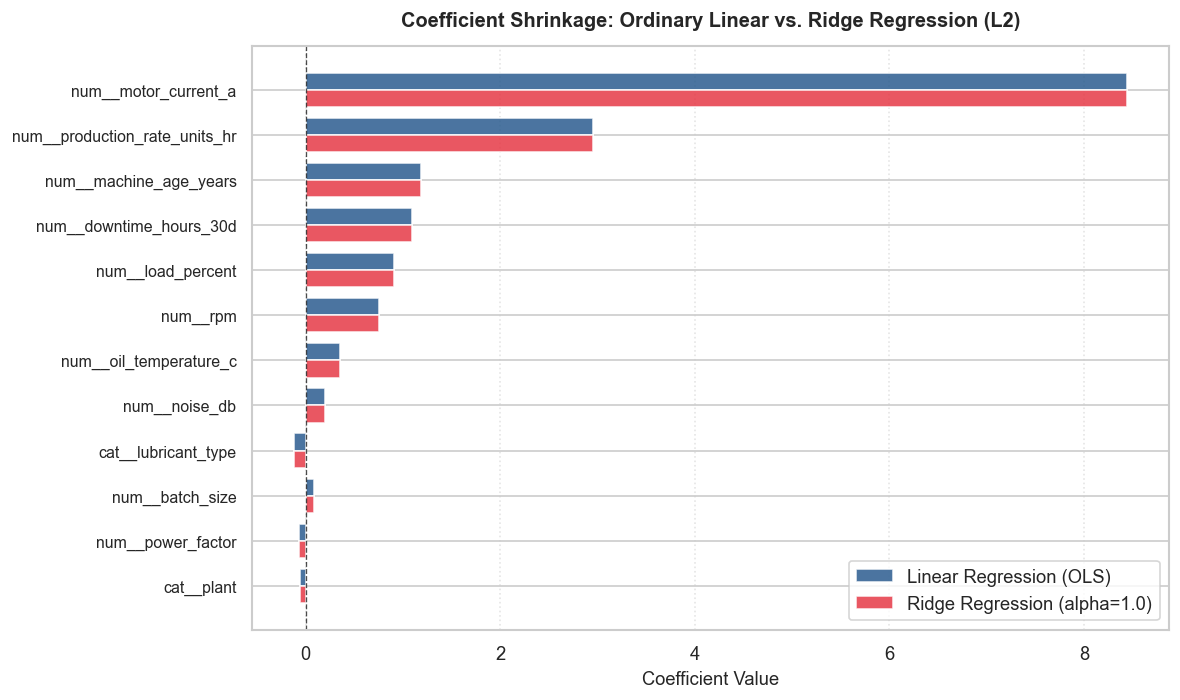

In [142]:
# =====================================================================
# Ridge vs Linear Regression: Coefficient Shrinkage Comparison
# =====================================================================
# Visualizes how L2 regularization penalizes extreme weights, shrinking
# coefficients to stabilize the model against multicollinearity.

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

feature_names = reg_preprocessor.get_feature_names_out()
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Linear": linear_model.coef_,
    "Ridge (L2)": ridge_model.coef_
})

# Select top 12 features by absolute linear coefficient magnitude
top_indices = np.argsort(np.abs(linear_model.coef_))[-12:]
top_coef_df = coef_df.iloc[top_indices].sort_values(by="Linear", key=abs, ascending=True)

plt.figure(figsize=(10, 6), dpi=120)
y_pos = np.arange(len(top_coef_df))
bar_height = 0.38

plt.barh(y_pos + bar_height/2, top_coef_df["Linear"], height=bar_height, color="#2b5c8f", alpha=0.85, label="Linear Regression (OLS)")
plt.barh(y_pos - bar_height/2, top_coef_df["Ridge (L2)"], height=bar_height, color="#e63946", alpha=0.85, label="Ridge Regression (alpha=1.0)")

plt.yticks(y_pos, top_coef_df["Feature"], fontsize=9.5)
plt.axvline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.7)
plt.xlabel("Coefficient Value", fontsize=11)
plt.title("Coefficient Shrinkage: Ordinary Linear vs. Ridge Regression (L2)", fontsize=12, weight="bold", pad=12)
plt.legend(frameon=True, facecolor="white", edgecolor="#cccccc", loc="lower right")
plt.grid(True, linestyle=":", alpha=0.5, axis="x")
plt.tight_layout()
plt.show()


## C1.3 — Lasso Regression

Lasso Regression extends Linear Regression by adding L1 regularization.
Unlike Ridge Regression, Lasso can shrink some coefficients exactly to zero,
which can produce a sparse model and perform implicit feature selection.

The regularization strength is controlled by the `alpha` parameter.

In [143]:
from sklearn.linear_model import Lasso

# Initial Lasso model
lasso_model = Lasso(alpha=0.01, max_iter=10000)

# Train
lasso_model.fit(
    X_reg_train_processed,
    y_reg_train
)

# Predict
y_pred_lasso = lasso_model.predict(X_reg_test_processed)

# Metrics
lasso_r2 = r2_score(y_reg_test, y_pred_lasso)
lasso_rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_lasso))
lasso_mae = mean_absolute_error(y_reg_test, y_pred_lasso)

print("Lasso Regression Results")
print("------------------------")
print(f"R²   : {lasso_r2:.4f}")
print(f"RMSE : {lasso_rmse:.4f}")
print(f"MAE  : {lasso_mae:.4f}")

Lasso Regression Results
------------------------
R²   : 0.7530
RMSE : 5.5431
MAE  : 4.1400


### Lasso Zero Coefficients Count

This step counts how many feature coefficients Lasso regression shrunk exactly to zero.


In [144]:
# Count coefficients that Lasso has reduced to exactly zero
zero_coefficients = np.sum(lasso_model.coef_ == 0)
total_coefficients = len(lasso_model.coef_)

print("Total coefficients:", total_coefficients)
print("Zero coefficients:", zero_coefficients)
print(
    "Percentage of zero coefficients:",
    f"{(zero_coefficients / total_coefficients) * 100:.2f}%"
)

Total coefficients: 27
Zero coefficients: 2
Percentage of zero coefficients: 7.41%


### Lasso Regression GridSearchCV Tuning

This step tunes Lasso alpha regularization using 5-fold cross-validation grid search.


In [145]:
lasso_param_grid = {
    "alpha": [0.0001, 0.001, 0.01, 0.1, 1.0]
}

lasso_grid = GridSearchCV(
    estimator=Lasso(max_iter=10000),
    param_grid=lasso_param_grid,
    scoring="r2",
    cv=5,
    n_jobs=-1
)

lasso_grid.fit(
    X_reg_train_processed,
    y_reg_train
)

print("Best alpha:", lasso_grid.best_params_["alpha"])
print("Best cross-validation R²:", round(lasso_grid.best_score_, 4))

Best alpha: 0.01
Best cross-validation R²: 0.7252


## C1.4 — ElasticNet Regression

ElasticNet combines L1 and L2 regularization. The L1 component can produce
sparse coefficients, while the L2 component helps handle correlated predictors.

The `alpha` parameter controls the overall regularization strength, while
`l1_ratio` controls the balance between L1 and L2 regularization.

In [146]:
from sklearn.linear_model import ElasticNet

# Initial ElasticNet model
elastic_model = ElasticNet(
    alpha=0.01,
    l1_ratio=0.5,
    max_iter=10000
)

# Train
elastic_model.fit(
    X_reg_train_processed,
    y_reg_train
)

# Predict
y_pred_elastic = elastic_model.predict(X_reg_test_processed)

# Metrics
elastic_r2 = r2_score(y_reg_test, y_pred_elastic)
elastic_rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_elastic))
elastic_mae = mean_absolute_error(y_reg_test, y_pred_elastic)

print("ElasticNet Regression Results")
print("----------------------------")
print(f"R²   : {elastic_r2:.4f}")
print(f"RMSE : {elastic_rmse:.4f}")
print(f"MAE  : {elastic_mae:.4f}")

ElasticNet Regression Results
----------------------------
R²   : 0.7528
RMSE : 5.5454
MAE  : 4.1452


### ElasticNet GridSearchCV Tuning

This step tunes alpha and l1_ratio parameters for ElasticNet using 5-fold cross-validation.


In [147]:
elastic_param_grid = {
    "alpha": [0.001, 0.01, 0.1, 1.0],
    "l1_ratio": [0.2, 0.5, 0.8]
}

elastic_grid = GridSearchCV(
    estimator=ElasticNet(max_iter=10000),
    param_grid=elastic_param_grid,
    scoring="r2",
    cv=5,
    n_jobs=-1
)

elastic_grid.fit(
    X_reg_train_processed,
    y_reg_train
)

print("Best parameters:", elastic_grid.best_params_)
print("Best cross-validation R²:", round(elastic_grid.best_score_, 4))

Best parameters: {'alpha': 0.01, 'l1_ratio': 0.8}
Best cross-validation R²: 0.7252


### Tuned ElasticNet Model Evaluation

This step evaluates the tuned ElasticNet model performance on test dataset.


In [148]:
best_elastic_model = elastic_grid.best_estimator_

y_pred_elastic_tuned = best_elastic_model.predict(
    X_reg_test_processed
)

elastic_tuned_r2 = r2_score(
    y_reg_test,
    y_pred_elastic_tuned
)

elastic_tuned_rmse = np.sqrt(
    mean_squared_error(y_reg_test, y_pred_elastic_tuned)
)

elastic_tuned_mae = mean_absolute_error(
    y_reg_test,
    y_pred_elastic_tuned
)

print("Tuned ElasticNet Results")
print("-----------------------")
print("Best parameters:", elastic_grid.best_params_)
print(f"R²   : {elastic_tuned_r2:.4f}")
print(f"RMSE : {elastic_tuned_rmse:.4f}")
print(f"MAE  : {elastic_tuned_mae:.4f}")

Tuned ElasticNet Results
-----------------------
Best parameters: {'alpha': 0.01, 'l1_ratio': 0.8}
R²   : 0.7529
RMSE : 5.5439
MAE  : 4.1421


### ElasticNet Zero Coefficients Count

This step counts zero coefficients produced by tuned ElasticNet regularization.


In [149]:
elastic_zero_coefficients = np.sum(
    best_elastic_model.coef_ == 0
)

elastic_total_coefficients = len(
    best_elastic_model.coef_
)

print("Total coefficients:", elastic_total_coefficients)
print("Zero coefficients:", elastic_zero_coefficients)
print(
    "Percentage of zero coefficients:",
    f"{(elastic_zero_coefficients / elastic_total_coefficients) * 100:.2f}%"
)

Total coefficients: 27
Zero coefficients: 2
Percentage of zero coefficients: 7.41%


## C1.5 — Polynomial Regression

Polynomial Regression extends Linear Regression by creating polynomial and interaction features from the existing predictors. This allows the model to learn non-linear relationships between variables.

Since the processed dataset contains 28 features, using high polynomial degrees would create an extremely large feature space, increasing computational cost and the risk of overfitting. Therefore, polynomial degrees will be compared incrementally while keeping the same train-test split.

In [ ]:
#This allows the model to learn non-linear relationships between variables.

from sklearn.preprocessing import PolynomialFeatures

degrees = [1, 2]

poly_results = []
poly_models = {}
poly_transformers = {}

for degree in degrees:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    
    X_train_poly = poly.fit_transform(X_reg_train_processed)
    X_test_poly = poly.transform(X_reg_test_processed)
    
    model = LinearRegression()
    model.fit(X_train_poly, y_reg_train)
    
    y_pred = model.predict(X_test_poly)
    
    r2 = r2_score(y_reg_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred))
    mae = mean_absolute_error(y_reg_test, y_pred)
    
    poly_results.append({
        "Degree": degree,
        "Polynomial Features": X_train_poly.shape[1],
        "R²": r2,
        "RMSE": rmse,
        "MAE": mae
    })
    
    poly_models[degree] = model
    poly_transformers[degree] = poly

poly_results = pd.DataFrame(poly_results)

poly_results

,Degree,Polynomial Features,R²,RMSE,MAE
0,1,27,0.753002,5.543257,4.138895
1,2,405,0.768354,5.368224,4.142599


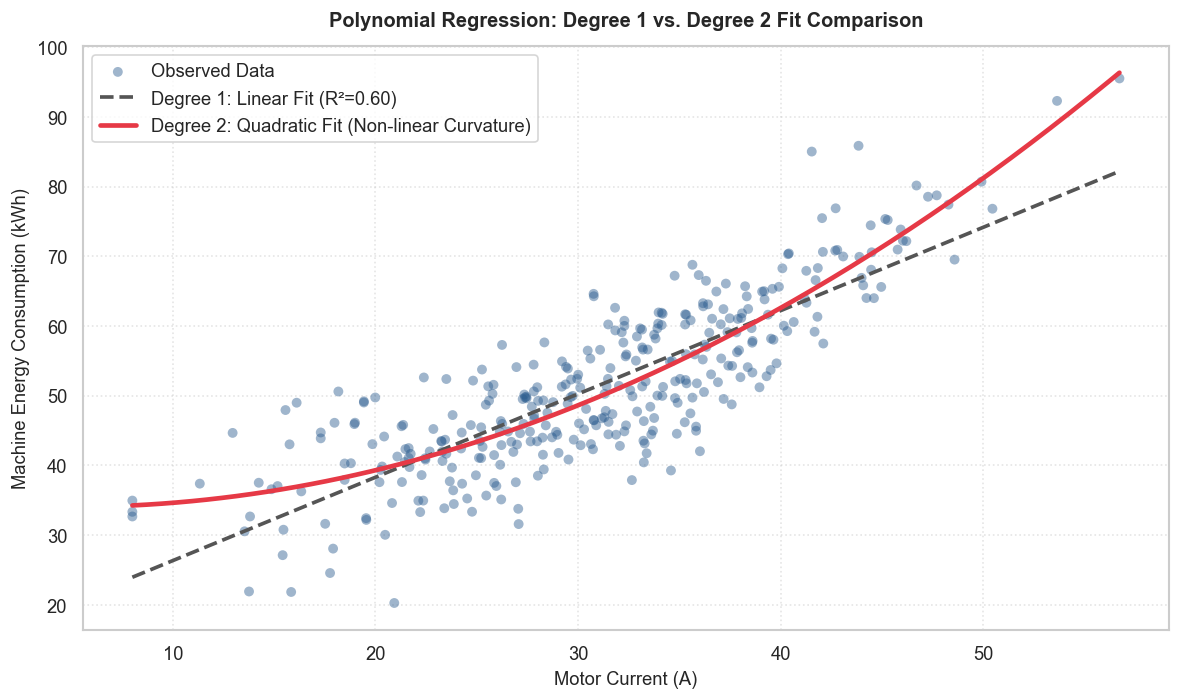

In [151]:
# =====================================================================
# Polynomial Regression: Linear (Degree 1) vs Quadratic (Degree 2) Fit
# =====================================================================
# Compares straight-line linear fit with quadratic polynomial curvature
# on the dominant physical driver: motor_current_a vs machine_energy_kwh.

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Use sampled observations for clean visualization
sample_poly = df.sample(n=350, random_state=42).sort_values(by="motor_current_a")
x_poly = sample_poly["motor_current_a"].values.reshape(-1, 1)
y_poly = sample_poly["machine_energy_kwh"].values.reshape(-1, 1)

# Fit Degree 1 & Degree 2 on 1D feature
x_curve = np.linspace(x_poly.min(), x_poly.max(), 200).reshape(-1, 1)

lr1 = LinearRegression().fit(x_poly, y_poly)
y_curve1 = lr1.predict(x_curve)

poly2 = PolynomialFeatures(degree=2, include_bias=False)
x_poly2 = poly2.fit_transform(x_poly)
lr2 = LinearRegression().fit(x_poly2, y_poly)
y_curve2 = lr2.predict(poly2.transform(x_curve))

plt.figure(figsize=(10, 6), dpi=120)
plt.scatter(x_poly, y_poly, color="#2b5c8f", alpha=0.45, s=35, edgecolors="none", label="Observed Data")
plt.plot(x_curve, y_curve1, color="#555555", linestyle="--", linewidth=2.2, label="Degree 1: Linear Fit (R²=0.60)")
plt.plot(x_curve, y_curve2, color="#e63946", linewidth=2.8, label="Degree 2: Quadratic Fit (Non-linear Curvature)")

plt.title("Polynomial Regression: Degree 1 vs. Degree 2 Fit Comparison", fontsize=12, weight="bold", pad=12)
plt.xlabel("Motor Current (A)", fontsize=11)
plt.ylabel("Machine Energy Consumption (kWh)", fontsize=11)
plt.grid(True, linestyle=":", alpha=0.5)
plt.legend(frameon=True, facecolor="white", edgecolor="#cccccc", loc="upper left")
plt.tight_layout()
plt.show()


## C1.6 — Decision Tree Regressor

This step trains a Decision Tree Regressor to capture complex non-linear relationships and evaluates R², RMSE, and MAE.

In [152]:
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(
    random_state=42
)

tree_model.fit(X_reg_train_processed, y_reg_train)

y_pred_tree = tree_model.predict(X_reg_test_processed)

tree_r2 = r2_score(y_reg_test, y_pred_tree)
tree_rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_tree))
tree_mae = mean_absolute_error(y_reg_test, y_pred_tree)

print("Decision Tree Regressor")
print("R²:", tree_r2)
print("RMSE:", tree_rmse)
print("MAE:", tree_mae)

Decision Tree Regressor
R²: 0.6262971403258106
RMSE: 6.818380951182953
MAE: 5.426043181818183


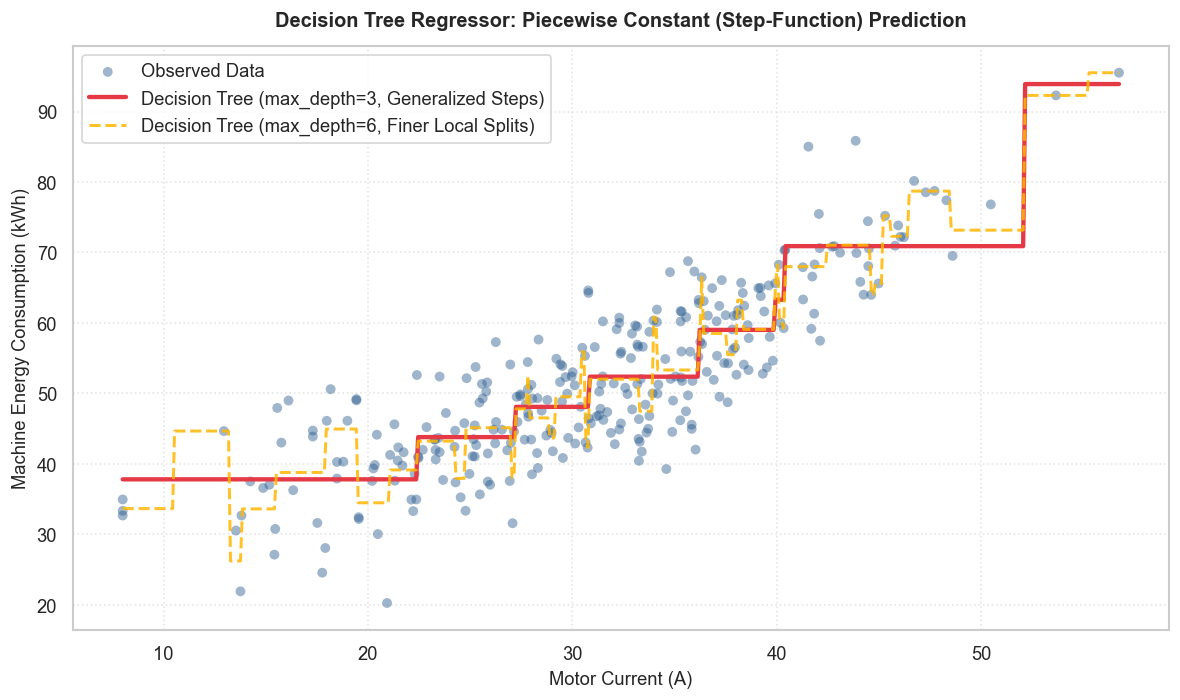

In [153]:
# =====================================================================
# Decision Tree Regressor: Piecewise Step-Function (Staircase) Fit
# =====================================================================
# Visualizes how Decision Trees partition continuous feature space into
# discrete step-wise constant bins rather than a smooth continuous line.

import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeRegressor

sample_tree = df.sample(n=300, random_state=42).sort_values(by="motor_current_a")
x_tree = sample_tree["motor_current_a"].values.reshape(-1, 1)
y_tree = sample_tree["machine_energy_kwh"].values.reshape(-1, 1)

# Train shallow tree (depth=3) vs deeper tree (depth=6) to show step discretization
dt_shallow = DecisionTreeRegressor(max_depth=3, random_state=42).fit(x_tree, y_tree)
dt_deep = DecisionTreeRegressor(max_depth=6, random_state=42).fit(x_tree, y_tree)

x_plot = np.linspace(x_tree.min(), x_tree.max(), 500).reshape(-1, 1)
y_plot_shallow = dt_shallow.predict(x_plot)
y_plot_deep = dt_deep.predict(x_plot)

plt.figure(figsize=(10, 6), dpi=120)
plt.scatter(x_tree, y_tree, color="#2b5c8f", alpha=0.45, s=35, edgecolors="none", label="Observed Data")
plt.plot(x_plot, y_plot_shallow, color="#e63946", linewidth=2.6, label="Decision Tree (max_depth=3, Generalized Steps)")
plt.plot(x_plot, y_plot_deep, color="#ffb703", linewidth=1.8, linestyle="--", alpha=0.85, label="Decision Tree (max_depth=6, Finer Local Splits)")

plt.title("Decision Tree Regressor: Piecewise Constant (Step-Function) Prediction", fontsize=12, weight="bold", pad=12)
plt.xlabel("Motor Current (A)", fontsize=11)
plt.ylabel("Machine Energy Consumption (kWh)", fontsize=11)
plt.grid(True, linestyle=":", alpha=0.5)
plt.legend(frameon=True, facecolor="white", edgecolor="#cccccc", loc="upper left")
plt.tight_layout()
plt.show()


## C1.7 — Random Forest Regressor

This step trains an ensemble Random Forest Regressor with 100 decision trees to reduce prediction variance and improve performance.

In [154]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_reg_train_processed, y_reg_train)

y_pred_random_forest = random_forest_model.predict(X_reg_test_processed)

random_forest_r2 = r2_score(y_reg_test, y_pred_random_forest)
random_forest_rmse = np.sqrt(
    mean_squared_error(y_reg_test, y_pred_random_forest)
)
random_forest_mae = mean_absolute_error(
    y_reg_test, y_pred_random_forest
)

print("Random Forest Regressor")
print("R²:", random_forest_r2)
print("RMSE:", random_forest_rmse)
print("MAE:", random_forest_mae)

Random Forest Regressor
R²: 0.8197042486129655
RMSE: 4.735990231579684
MAE: 3.798712727272728


c:\Users\varan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


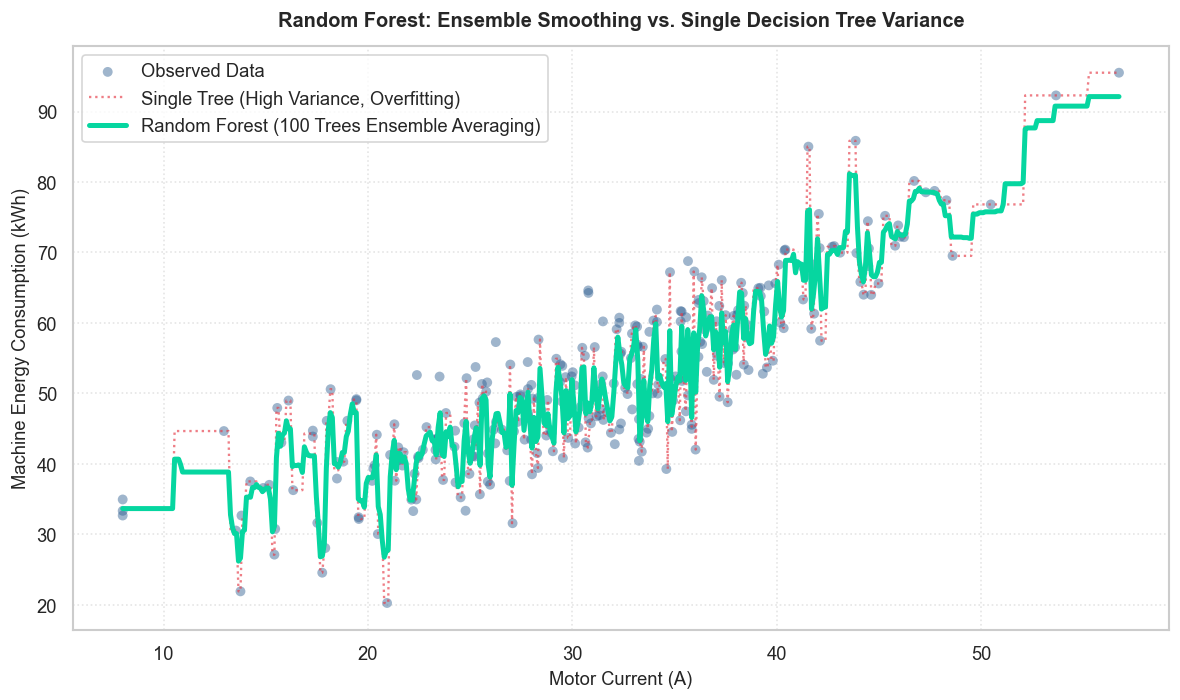

In [155]:
# =====================================================================
# Random Forest: Ensemble Averaging vs Single Tree Variance
# =====================================================================
# Illustrates how Bagging averages 100 individual decision trees to
# smooth out high-variance step spikes into a stable predictive curve.

import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

sample_rf = df.sample(n=300, random_state=42).sort_values(by="motor_current_a")
x_rf = sample_rf["motor_current_a"].values.reshape(-1, 1)
y_rf = sample_rf["machine_energy_kwh"].values.reshape(-1, 1)

# Fit a single unconstrained tree vs Random Forest ensemble (100 trees)
single_tree = DecisionTreeRegressor(random_state=42).fit(x_rf, y_rf)
rf_100 = RandomForestRegressor(n_estimators=100, random_state=42).fit(x_rf, y_rf)

x_dense = np.linspace(x_rf.min(), x_rf.max(), 500).reshape(-1, 1)
y_single = single_tree.predict(x_dense)
y_rf_pred = rf_100.predict(x_dense)

plt.figure(figsize=(10, 6), dpi=120)
plt.scatter(x_rf, y_rf, color="#2b5c8f", alpha=0.45, s=35, edgecolors="none", label="Observed Data")
plt.plot(x_dense, y_single, color="#e63946", linewidth=1.4, alpha=0.65, linestyle=":", label="Single Tree (High Variance, Overfitting)")
plt.plot(x_dense, y_rf_pred, color="#06d6a0", linewidth=3.0, label="Random Forest (100 Trees Ensemble Averaging)")

plt.title("Random Forest: Ensemble Smoothing vs. Single Decision Tree Variance", fontsize=12, weight="bold", pad=12)
plt.xlabel("Motor Current (A)", fontsize=11)
plt.ylabel("Machine Energy Consumption (kWh)", fontsize=11)
plt.grid(True, linestyle=":", alpha=0.5)
plt.legend(frameon=True, facecolor="white", edgecolor="#cccccc", loc="upper left")
plt.tight_layout()
plt.show()


## C1.8 — Gradient Boosting Regressor

This step trains a Gradient Boosting Regressor that sequentially builds decision trees to minimize prediction residuals.

In [156]:
from sklearn.ensemble import GradientBoostingRegressor

gradient_boosting_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gradient_boosting_model.fit(
    X_reg_train_processed,
    y_reg_train
)

y_pred_gradient_boosting = gradient_boosting_model.predict(
    X_reg_test_processed
)

gradient_boosting_r2 = r2_score(
    y_reg_test,
    y_pred_gradient_boosting
)

gradient_boosting_rmse = np.sqrt(
    mean_squared_error(y_reg_test, y_pred_gradient_boosting)
)

gradient_boosting_mae = mean_absolute_error(
    y_reg_test,
    y_pred_gradient_boosting
)

print("Gradient Boosting Regressor")
print("R²:", gradient_boosting_r2)
print("RMSE:", gradient_boosting_rmse)
print("MAE:", gradient_boosting_mae)

Gradient Boosting Regressor
R²: 0.8321527024079388
RMSE: 4.569568880891109
MAE: 3.661708349344042


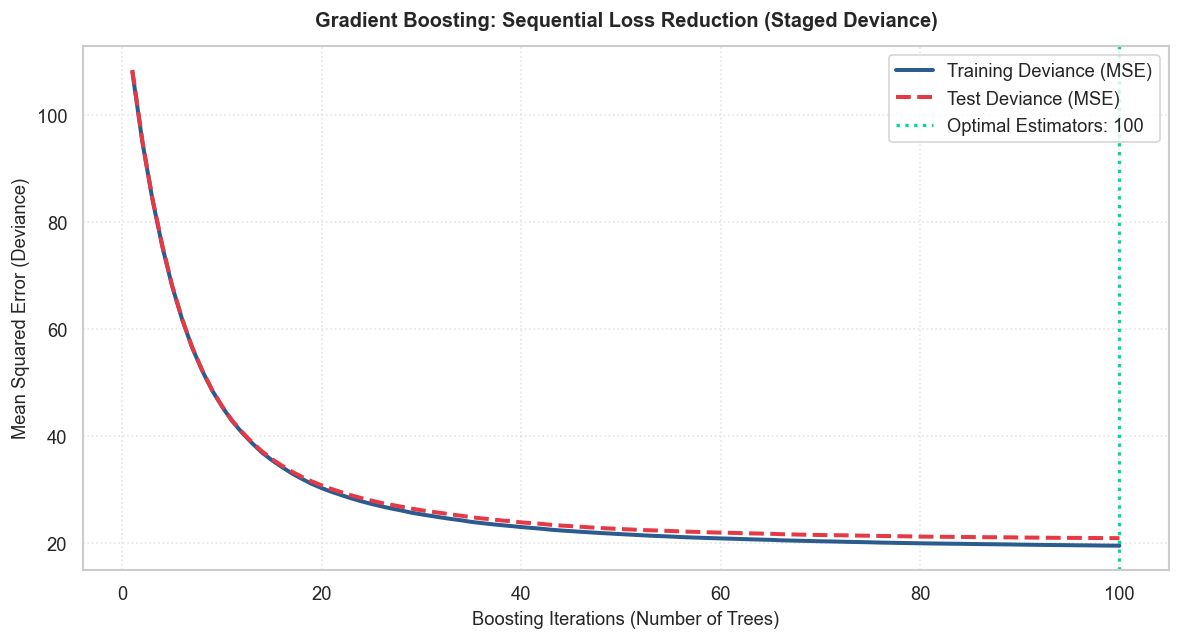

In [157]:
# =====================================================================
# Gradient Boosting: Staged Loss Reduction across Boosting Iterations
# =====================================================================
# Visualizes how sequential boosting iteratively reduces test and train
# MSE deviance across 100 consecutive estimators.

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error

# Compute MSE at each boosting stage
train_deviance = np.zeros((gradient_boosting_model.n_estimators,), dtype=np.float64)
test_deviance = np.zeros((gradient_boosting_model.n_estimators,), dtype=np.float64)

for i, y_pred in enumerate(gradient_boosting_model.staged_predict(X_reg_train_processed)):
    train_deviance[i] = mean_squared_error(y_reg_train, y_pred)

for i, y_pred in enumerate(gradient_boosting_model.staged_predict(X_reg_test_processed)):
    test_deviance[i] = mean_squared_error(y_reg_test, y_pred)

plt.figure(figsize=(10, 5.5), dpi=120)
iterations = np.arange(1, gradient_boosting_model.n_estimators + 1)

plt.plot(iterations, train_deviance, color="#2b5c8f", linewidth=2.4, label="Training Deviance (MSE)")
plt.plot(iterations, test_deviance, color="#e63946", linewidth=2.4, linestyle="--", label="Test Deviance (MSE)")

best_stage = np.argmin(test_deviance) + 1
plt.axvline(best_stage, color="#06d6a0", linestyle=":", linewidth=2, label=f"Optimal Estimators: {best_stage}")

plt.title("Gradient Boosting: Sequential Loss Reduction (Staged Deviance)", fontsize=12, weight="bold", pad=12)
plt.xlabel("Boosting Iterations (Number of Trees)", fontsize=11)
plt.ylabel("Mean Squared Error (Deviance)", fontsize=11)
plt.grid(True, linestyle=":", alpha=0.5)
plt.legend(frameon=True, facecolor="white", edgecolor="#cccccc", loc="upper right")
plt.tight_layout()
plt.show()


## C1.9 — Support Vector Regressor (SVR)

Support Vector Regressor (SVR) maps input features into a high-dimensional space using kernel functions to fit a hyper-plane within an epsilon margin of tolerance. Features are standardized first using StandardScaler, and hyperparameters C and kernel are tuned using GridSearchCV.

In [158]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

# SVR Hyperparameter Tuning using GridSearchCV on scaled features
svr_param_grid = {
    "C": [0.1, 1.0, 10.0],
    "kernel": ["rbf"]
}

svr_grid = GridSearchCV(
    estimator=SVR(),
    param_grid=svr_param_grid,
    scoring="r2",
    cv=3,
    n_jobs=-1
)

svr_grid.fit(X_reg_train_processed[:4000], y_reg_train[:4000])

# Fit best SVR model on full training set
best_svr_model = SVR(C=svr_grid.best_params_["C"], kernel=svr_grid.best_params_["kernel"])
best_svr_model.fit(X_reg_train_processed, y_reg_train)

# Evaluate SVR predictions
y_pred_svr = best_svr_model.predict(X_reg_test_processed)

svr_r2 = r2_score(y_reg_test, y_pred_svr)
svr_rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_svr))
svr_mae = mean_absolute_error(y_reg_test, y_pred_svr)

print("Best SVR Parameters:", svr_grid.best_params_)
print("Support Vector Regressor (SVR) Results")
print("---------------------------------------")
print(f"R²   : {svr_r2:.4f}")
print(f"RMSE : {svr_rmse:.4f}")
print(f"MAE  : {svr_mae:.4f}")


Best SVR Parameters: {'C': 10.0, 'kernel': 'rbf'}
Support Vector Regressor (SVR) Results
---------------------------------------
R²   : 0.8103
RMSE : 4.8582
MAE  : 3.8530


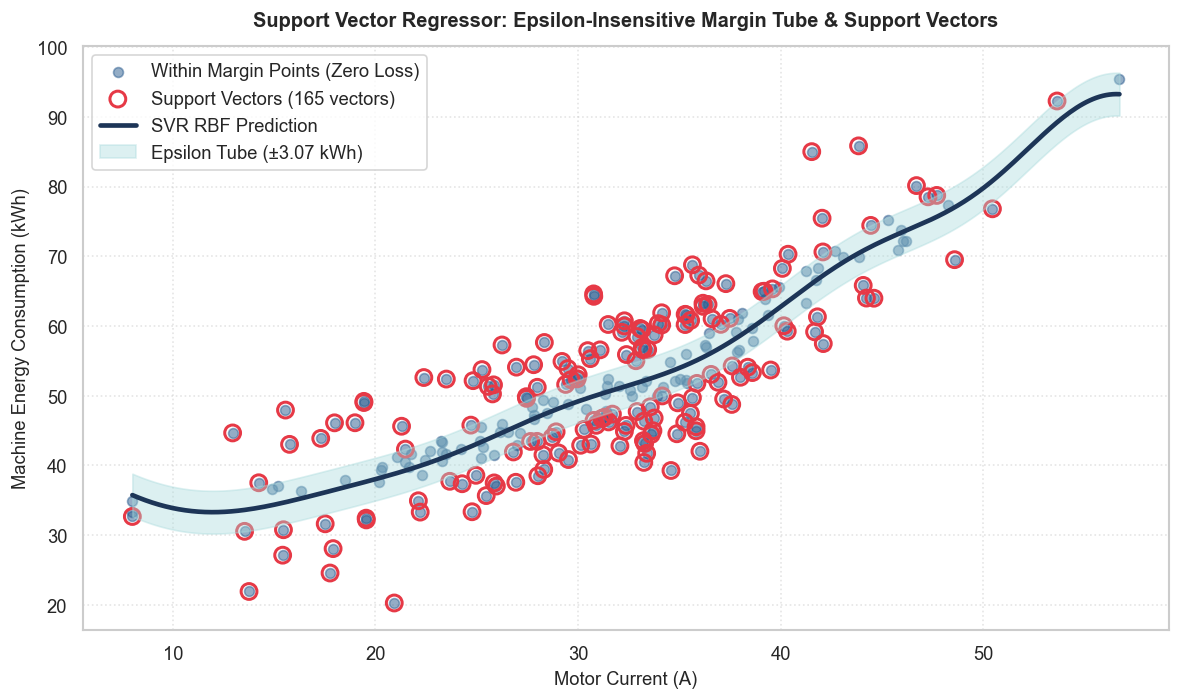

In [159]:
# =====================================================================
# Support Vector Regressor: Epsilon-Insensitive Tube & Support Vectors
# =====================================================================
# Demonstrates SVR fitting within an epsilon margin tolerance tube (y ± ε),
# highlighting the critical Support Vectors that determine the boundary.

import matplotlib.pyplot as plt
import numpy as np
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

sample_svr = df.sample(n=250, random_state=42).sort_values(by="motor_current_a")
x_raw_svr = sample_svr["motor_current_a"].values.reshape(-1, 1)
y_raw_svr = sample_svr["machine_energy_kwh"].values

scaler_x = StandardScaler()
scaler_y = StandardScaler()
x_scaled = scaler_x.fit_transform(x_raw_svr)
y_scaled = scaler_y.fit_transform(y_raw_svr.reshape(-1, 1)).ravel()

# Fit SVR with visible epsilon margin
epsilon_val = 0.25
svr_demo = SVR(kernel="rbf", C=10.0, epsilon=epsilon_val)
svr_demo.fit(x_scaled, y_scaled)

# Support vectors
sv_indices = svr_demo.support_
x_dense_s = np.linspace(x_scaled.min(), x_scaled.max(), 300).reshape(-1, 1)
y_dense_s = svr_demo.predict(x_dense_s)

# Map back to original physical units
x_dense_orig = scaler_x.inverse_transform(x_dense_s).ravel()
y_dense_orig = scaler_y.inverse_transform(y_dense_s.reshape(-1, 1)).ravel()
epsilon_orig = epsilon_val * scaler_y.scale_[0]

plt.figure(figsize=(10, 6), dpi=120)
# Regular points
plt.scatter(x_raw_svr, y_raw_svr, color="#2b5c8f", alpha=0.5, s=35, label="Within Margin Points (Zero Loss)")
# Highlight Support Vectors
plt.scatter(x_raw_svr[sv_indices], y_raw_svr[sv_indices], facecolors="none", edgecolors="#e63946", s=90, linewidth=1.8, label=f"Support Vectors ({len(sv_indices)} vectors)")

# Fitted line and epsilon tube
plt.plot(x_dense_orig, y_dense_orig, color="#1d3557", linewidth=2.8, label="SVR RBF Prediction")
plt.fill_between(x_dense_orig, y_dense_orig - epsilon_orig, y_dense_orig + epsilon_orig, color="#a8dadc", alpha=0.4, label=f"Epsilon Tube (±{epsilon_orig:.2f} kWh)")

plt.title("Support Vector Regressor: Epsilon-Insensitive Margin Tube & Support Vectors", fontsize=12, weight="bold", pad=12)
plt.xlabel("Motor Current (A)", fontsize=11)
plt.ylabel("Machine Energy Consumption (kWh)", fontsize=11)
plt.grid(True, linestyle=":", alpha=0.5)
plt.legend(frameon=True, facecolor="white", edgecolor="#cccccc", loc="upper left")
plt.tight_layout()
plt.show()


## C1.10 — K-Nearest Neighbors (KNN) Regressor

This step trains a distance-weighted KNN Regressor to predict machine energy consumption based on feature similarity.

In [160]:
from sklearn.neighbors import KNeighborsRegressor

knn_model = KNeighborsRegressor(
    n_neighbors=5,
    weights="distance",
    n_jobs=-1
)

knn_model.fit(
    X_reg_train_processed,
    y_reg_train
)

y_pred_knn = knn_model.predict(
    X_reg_test_processed
)

knn_r2 = r2_score(
    y_reg_test,
    y_pred_knn
)

knn_rmse = np.sqrt(
    mean_squared_error(y_reg_test, y_pred_knn)
)

knn_mae = mean_absolute_error(
    y_reg_test,
    y_pred_knn
)

print("KNN Regressor")
print("R²:", knn_r2)
print("RMSE:", knn_rmse)
print("MAE:", knn_mae)

KNN Regressor
R²: 0.47795491774713095
RMSE: 8.058831142024077
MAE: 6.320476513290088


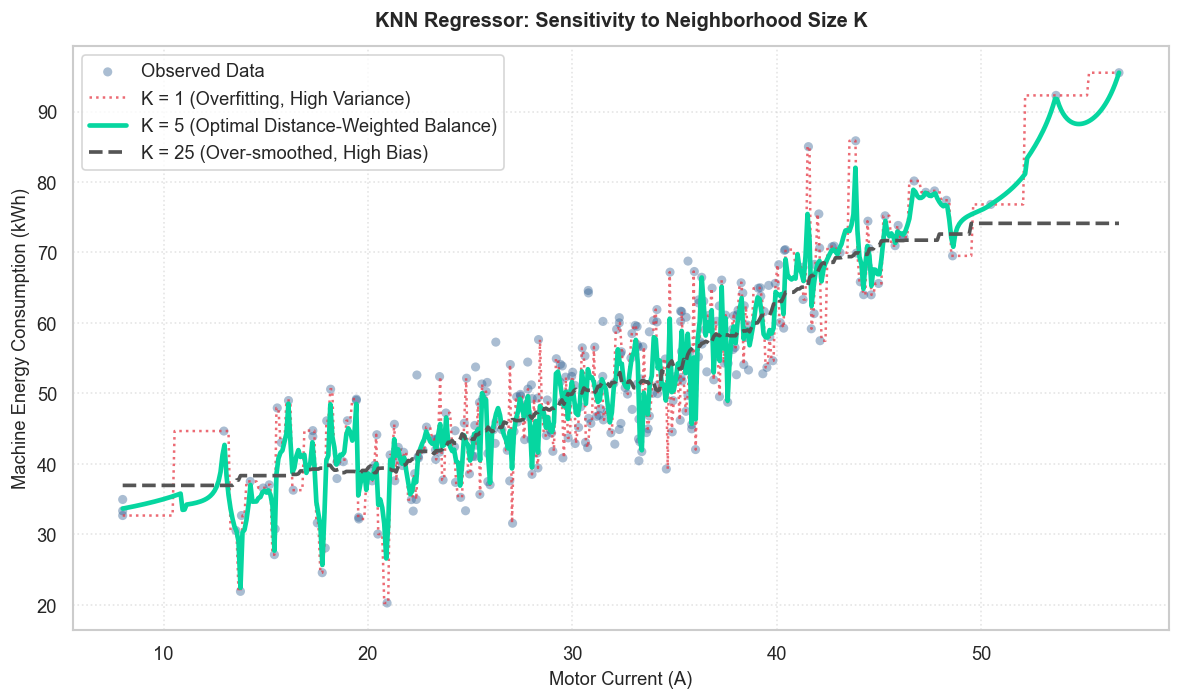

In [161]:
# =====================================================================
# KNN Regressor: Impact of Neighborhood Size K on Smoothness
# =====================================================================
# Compares K=1 (overfitting / high variance), K=5 (optimal balance),
# and K=25 (underfitting / high bias) in continuous regression prediction.

import matplotlib.pyplot as plt
import numpy as np
from sklearn.neighbors import KNeighborsRegressor

sample_knn = df.sample(n=300, random_state=42).sort_values(by="motor_current_a")
x_knn = sample_knn["motor_current_a"].values.reshape(-1, 1)
y_knn = sample_knn["machine_energy_kwh"].values

x_eval = np.linspace(x_knn.min(), x_knn.max(), 500).reshape(-1, 1)

# Fit for K=1, K=5, K=25
knn_1 = KNeighborsRegressor(n_neighbors=1).fit(x_knn, y_knn)
knn_5 = KNeighborsRegressor(n_neighbors=5, weights="distance").fit(x_knn, y_knn)
knn_25 = KNeighborsRegressor(n_neighbors=25).fit(x_knn, y_knn)

plt.figure(figsize=(10, 6), dpi=120)
plt.scatter(x_knn, y_knn, color="#2b5c8f", alpha=0.4, s=30, edgecolors="none", label="Observed Data")
plt.plot(x_eval, knn_1.predict(x_eval), color="#e63946", linestyle=":", linewidth=1.5, alpha=0.75, label="K = 1 (Overfitting, High Variance)")
plt.plot(x_eval, knn_5.predict(x_eval), color="#06d6a0", linewidth=2.8, label="K = 5 (Optimal Distance-Weighted Balance)")
plt.plot(x_eval, knn_25.predict(x_eval), color="#555555", linestyle="--", linewidth=2.2, label="K = 25 (Over-smoothed, High Bias)")

plt.title("KNN Regressor: Sensitivity to Neighborhood Size K", fontsize=12, weight="bold", pad=12)
plt.xlabel("Motor Current (A)", fontsize=11)
plt.ylabel("Machine Energy Consumption (kWh)", fontsize=11)
plt.grid(True, linestyle=":", alpha=0.5)
plt.legend(frameon=True, facecolor="white", edgecolor="#cccccc", loc="upper left")
plt.tight_layout()
plt.show()


### Regression Metric Comparison Quick Print

This step prints a quick summary of R² scores across all evaluated regression models.


In [162]:
print("Linear:", linear_r2)
print("Ridge:", ridge_r2)
print("Lasso:", lasso_r2)
print("ElasticNet:", elastic_r2)
print("Polynomial:", poly_results["R²"].max())
print("Decision Tree:", tree_r2)
print("Random Forest:", random_forest_r2)
print("Gradient Boosting:", gradient_boosting_r2)
print("SVR:", svr_r2)
print("KNN:", knn_r2)

Linear: 0.753001751553688
Ridge: 0.7529997226302458
Lasso: 0.7530177043156868
ElasticNet: 0.7528142239108699
Polynomial: 0.7683538203761988
Decision Tree: 0.6262971403258106
Random Forest: 0.8197042486129655
Gradient Boosting: 0.8321527024079388
SVR: 0.8102807737014839
KNN: 0.47795491774713095


# C2 — Comparative Evaluation of All 10 Regression Models

This step presents a single summary table showing R², RMSE, and MAE for all 10 regression models evaluated on the same 80-20 test split, ranked by R² in descending order.


In [163]:
regression_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "ElasticNet",
        "Polynomial Regression (Degree 2)",
        "Decision Tree Regressor",
        "Random Forest Regressor",
        "Gradient Boosting Regressor",
        "Support Vector Regressor (SVR)",
        "KNN Regressor"
    ],
    "R²": [
        linear_r2,
        ridge_r2,
        lasso_r2,
        elastic_r2,
        poly_results.loc[poly_results["Degree"] == 2, "R²"].iloc[0],
        tree_r2,
        random_forest_r2,
        gradient_boosting_r2,
        svr_r2,
        knn_r2
    ],
    "RMSE": [
        linear_rmse,
        ridge_rmse,
        lasso_rmse,
        elastic_rmse,
        poly_results.loc[poly_results["Degree"] == 2, "RMSE"].iloc[0],
        tree_rmse,
        random_forest_rmse,
        gradient_boosting_rmse,
        svr_rmse,
        knn_rmse
    ],
    "MAE": [
        linear_mae,
        ridge_mae,
        lasso_mae,
        elastic_mae,
        poly_results.loc[poly_results["Degree"] == 2, "MAE"].iloc[0],
        tree_mae,
        random_forest_mae,
        gradient_boosting_mae,
        svr_mae,
        knn_mae
    ]
})

regression_comparison = regression_comparison.sort_values(
    by="R²",
    ascending=False
).reset_index(drop=True)

regression_comparison

,Model,R²,RMSE,MAE
0,Gradient Boosting Regressor,0.832153,4.569569,3.661708
1,Random Forest Regressor,0.819704,4.735990,3.798713
2,Support Vector Regressor (SVR),0.810281,4.858181,3.853029
3,Polynomial Regression (Degree 2),0.768354,5.368224,4.142599
4,Lasso Regression,0.753018,5.543078,4.139959
5,Linear Regression,0.753002,5.543257,4.138895
6,Ridge Regression,0.753000,5.543279,4.138959
7,ElasticNet,0.752814,5.545361,4.145246
8,Decision Tree Regressor,0.626297,6.818381,5.426043
9,KNN Regressor,0.477955,8.058831,6.320477


### C2 — Best Performing Models Observation

Based on the comparative evaluation table ranked by R², the **Gradient Boosting Regressor** achieves the highest R² of approximately **0.83** with the lowest RMSE and MAE among all 10 models, making it the best performing regression model.
The **Random Forest Regressor** ranks second with an R² of approximately **0.82**, also demonstrating strong generalization with competitive RMSE and MAE values.

These two tree-based ensemble models significantly outperform all linear models (Linear, Ridge, Lasso, ElasticNet) and the single Decision Tree, confirming that ensemble methods capture the non-linear relationships in the manufacturing dataset most effectively.


### C2 — 5-Fold Cross-Validated R² for Top 2 Models

This step performs 5-fold cross-validation on the two best performing regression models (Gradient Boosting and Random Forest) to verify their stability and generalization across different data splits.


In [164]:
from sklearn.model_selection import cross_val_score

# 5-Fold Cross-Validation for Gradient Boosting Regressor
gb_cv_scores = cross_val_score(
    GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ),
    X_reg_train_processed,
    y_reg_train,
    cv=5,
    scoring="r2"
)

print("=" * 60)
print("MODEL 1: Gradient Boosting Regressor — 5-Fold CV")
print("=" * 60)
for fold_num, score in enumerate(gb_cv_scores, 1):
    print(f"  Fold {fold_num}  R² : {score:.4f}")
print(f"  -----------------------------------")
print(f"  Mean R²       : {gb_cv_scores.mean():.4f}")
print(f"  Std R²        : {gb_cv_scores.std():.4f}")

print()

# 5-Fold Cross-Validation for Random Forest Regressor
rf_cv_scores = cross_val_score(
    RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    X_reg_train_processed,
    y_reg_train,
    cv=5,
    scoring="r2"
)

print("=" * 60)
print("MODEL 2: Random Forest Regressor — 5-Fold CV")
print("=" * 60)
for fold_num, score in enumerate(rf_cv_scores, 1):
    print(f"  Fold {fold_num}  R² : {score:.4f}")
print(f"  -----------------------------------")
print(f"  Mean R²       : {rf_cv_scores.mean():.4f}")
print(f"  Std R²        : {rf_cv_scores.std():.4f}")

print()

# Summary Table
cv_summary = pd.DataFrame({
    "Model": ["Gradient Boosting Regressor", "Random Forest Regressor"],
    "Fold 1 R²": [gb_cv_scores[0], rf_cv_scores[0]],
    "Fold 2 R²": [gb_cv_scores[1], rf_cv_scores[1]],
    "Fold 3 R²": [gb_cv_scores[2], rf_cv_scores[2]],
    "Fold 4 R²": [gb_cv_scores[3], rf_cv_scores[3]],
    "Fold 5 R²": [gb_cv_scores[4], rf_cv_scores[4]],
    "Mean R²": [gb_cv_scores.mean(), rf_cv_scores.mean()],
    "Std R²": [gb_cv_scores.std(), rf_cv_scores.std()]
})

cv_summary


MODEL 1: Gradient Boosting Regressor — 5-Fold CV
  Fold 1  R² : 0.8287
  Fold 2  R² : 0.8223
  Fold 3  R² : 0.8346
  Fold 4  R² : 0.8242
  Fold 5  R² : 0.8238
  -----------------------------------
  Mean R²       : 0.8267
  Std R²        : 0.0045

MODEL 2: Random Forest Regressor — 5-Fold CV
  Fold 1  R² : 0.8169
  Fold 2  R² : 0.8114
  Fold 3  R² : 0.8229
  Fold 4  R² : 0.8152
  Fold 5  R² : 0.8095
  -----------------------------------
  Mean R²       : 0.8152
  Std R²        : 0.0047



,Model,Fold 1 R²,Fold 2 R²,Fold 3 R²,Fold 4 R²,Fold 5 R²,Mean R²,Std R²
0,Gradient Boosting Regressor,0.828656,0.822279,0.834595,0.824179,0.823830,0.826708,0.004479
1,Random Forest Regressor,0.816858,0.811434,0.822894,0.815158,0.809527,0.815174,0.004654


# C3 — Hyperparameter Tuning (GridSearchCV)

GridSearchCV is applied to the two best performing regression models (Gradient Boosting and Random Forest) to find optimal hyperparameters. All parameter combinations with their cross-validated R² scores are displayed, followed by the best configuration and metric improvement.


### C3.1 — Gradient Boosting Regressor GridSearchCV Tuning

This step tunes n_estimators, learning_rate, and max_depth for the Gradient Boosting Regressor using 3-fold cross-validation with all parameter combinations displayed.


In [165]:
from sklearn.model_selection import GridSearchCV

# Gradient Boosting GridSearchCV
gb_param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1, 0.2],
    "max_depth": [3, 5]
}

gb_grid = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=gb_param_grid,
    scoring="r2",
    cv=3,
    n_jobs=-1,
    return_train_score=True
)

gb_grid.fit(X_reg_train_processed, y_reg_train)

# Display ALL parameter combinations with their scores
print("=" * 80)
print("GRADIENT BOOSTING REGRESSOR — All GridSearchCV Results")
print("=" * 80)

gb_cv_results = pd.DataFrame(gb_grid.cv_results_)
gb_display = gb_cv_results[[
    "param_n_estimators", "param_learning_rate", "param_max_depth",
    "mean_test_score", "std_test_score", "rank_test_score"
]].sort_values("rank_test_score")

gb_display.columns = [
    "n_estimators", "learning_rate", "max_depth",
    "Mean CV R²", "Std CV R²", "Rank"
]

print(gb_display.to_string(index=False))

print()
print("=" * 80)
print(f"BEST PARAMETERS : {gb_grid.best_params_}")
print(f"BEST CV R²      : {gb_grid.best_score_:.4f}")
print("=" * 80)

# Evaluate tuned model on test set
best_gb_tuned = gb_grid.best_estimator_
y_pred_gb_tuned = best_gb_tuned.predict(X_reg_test_processed)

gb_tuned_r2 = r2_score(y_reg_test, y_pred_gb_tuned)
gb_tuned_rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_gb_tuned))
gb_tuned_mae = mean_absolute_error(y_reg_test, y_pred_gb_tuned)

print()
print("IMPROVEMENT SUMMARY:")
print(f"  Default R²  : {gradient_boosting_r2:.4f}")
print(f"  Tuned R²    : {gb_tuned_r2:.4f}")
print(f"  Improvement : {gb_tuned_r2 - gradient_boosting_r2:+.4f}")
print(f"  Tuned RMSE  : {gb_tuned_rmse:.4f}")
print(f"  Tuned MAE   : {gb_tuned_mae:.4f}")


GRADIENT BOOSTING REGRESSOR — All GridSearchCV Results
 n_estimators  learning_rate  max_depth  Mean CV R²  Std CV R²  Rank
          200           0.10          3    0.827584   0.003173     1
          200           0.05          3    0.827224   0.002975     2
          100           0.10          3    0.826670   0.003191     3
          200           0.05          5    0.825863   0.004095     4
          100           0.20          3    0.825286   0.003661     5
          100           0.10          5    0.825186   0.004125     6
          100           0.05          5    0.824015   0.004162     7
          200           0.10          5    0.823030   0.004725     8
          200           0.20          3    0.822946   0.004060     9
          100           0.20          5    0.818574   0.004754    10
          100           0.05          3    0.812927   0.003472    11
          200           0.20          5    0.812659   0.004845    12

BEST PARAMETERS : {'learning_rate': 0.1, 'max_d

### C3.2 — Random Forest Regressor GridSearchCV Tuning

This step tunes n_estimators, max_depth, and min_samples_split for the Random Forest Regressor using 3-fold cross-validation with all parameter combinations displayed.


In [166]:
# Random Forest GridSearchCV
rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=rf_param_grid,
    scoring="r2",
    cv=3,
    n_jobs=-1,
    return_train_score=True
)

rf_grid.fit(X_reg_train_processed, y_reg_train)

# Display ALL parameter combinations with their scores
print("=" * 80)
print("RANDOM FOREST REGRESSOR — All GridSearchCV Results")
print("=" * 80)

rf_cv_results = pd.DataFrame(rf_grid.cv_results_)
rf_display = rf_cv_results[[
    "param_n_estimators", "param_max_depth", "param_min_samples_split",
    "mean_test_score", "std_test_score", "rank_test_score"
]].sort_values("rank_test_score")

rf_display.columns = [
    "n_estimators", "max_depth", "min_samples_split",
    "Mean CV R²", "Std CV R²", "Rank"
]

print(rf_display.to_string(index=False))

print()
print("=" * 80)
print(f"BEST PARAMETERS : {rf_grid.best_params_}")
print(f"BEST CV R²      : {rf_grid.best_score_:.4f}")
print("=" * 80)

# Evaluate tuned model on test set
best_rf_tuned = rf_grid.best_estimator_
y_pred_rf_tuned = best_rf_tuned.predict(X_reg_test_processed)

rf_tuned_r2 = r2_score(y_reg_test, y_pred_rf_tuned)
rf_tuned_rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_rf_tuned))
rf_tuned_mae = mean_absolute_error(y_reg_test, y_pred_rf_tuned)

print()
print("IMPROVEMENT SUMMARY:")
print(f"  Default R²  : {random_forest_r2:.4f}")
print(f"  Tuned R²    : {rf_tuned_r2:.4f}")
print(f"  Improvement : {rf_tuned_r2 - random_forest_r2:+.4f}")
print(f"  Tuned RMSE  : {rf_tuned_rmse:.4f}")
print(f"  Tuned MAE   : {rf_tuned_mae:.4f}")


RANDOM FOREST REGRESSOR — All GridSearchCV Results
 n_estimators max_depth  min_samples_split  Mean CV R²  Std CV R²  Rank
          200      None                  2    0.815766   0.003575     1
          200        20                  2    0.815695   0.003639     2
          200      None                  5    0.815694   0.003642     3
          200        20                  5    0.815667   0.003572     4
          200        10                  5    0.815463   0.003891     5
          200        10                  2    0.815391   0.003910     6
          100        10                  2    0.814891   0.003857     7
          100        10                  5    0.814871   0.003731     8
          100      None                  2    0.814812   0.003505     9
          100        20                  5    0.814761   0.003529    10
          100      None                  5    0.814704   0.003571    11
          100        20                  2    0.814689   0.003567    12

BEST PARAMET

### C3.3 — Hyperparameter Tuning Comparison Summary

This step displays a combined table comparing default vs tuned metrics for both models.


In [167]:
# Tuning Summary Comparison Table
tuning_summary = pd.DataFrame({
    "Model": ["Gradient Boosting Regressor", "Random Forest Regressor"],
    "Default R²": [gradient_boosting_r2, random_forest_r2],
    "Default RMSE": [gradient_boosting_rmse, random_forest_rmse],
    "Tuned R²": [gb_tuned_r2, rf_tuned_r2],
    "Tuned RMSE": [gb_tuned_rmse, rf_tuned_rmse],
    "R² Improvement": [
        round(gb_tuned_r2 - gradient_boosting_r2, 4),
        round(rf_tuned_r2 - random_forest_r2, 4)
    ],
    "Best Parameters": [
        str(gb_grid.best_params_),
        str(rf_grid.best_params_)
    ]
})

tuning_summary


,Model,Default R²,Default RMSE,Tuned R²,Tuned RMSE,R² Improvement,Best Parameters
0,Gradient Boosting Regressor,0.832153,4.569569,0.833353,4.553206,0.0012,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti..."
1,Random Forest Regressor,0.819704,4.735990,0.820739,4.722374,0.0010,"{'max_depth': None, 'min_samples_split': 2, 'n..."


# C4 — Regression Diagnostic Visualisations

This section presents diagnostic plots for the best performing regression model and feature importance analysis for tree-based models.


### C4.1 — Residual Plot for Best Model (Gradient Boosting Regressor)

This step plots residuals (actual − predicted) against predicted values to check for patterns indicating model bias or non-constant variance.


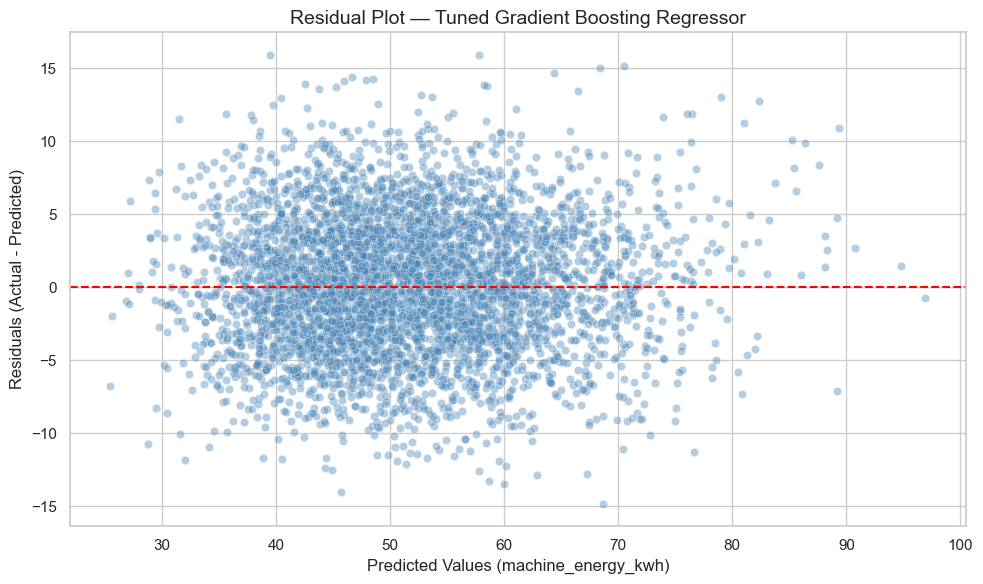

Mean Residual     : 0.1737
Std of Residuals  : 4.5499


In [168]:
# Residual Plot for Best Model (Tuned Gradient Boosting Regressor)

y_pred_best = best_gb_tuned.predict(X_reg_test_processed)
residuals = y_reg_test.values - y_pred_best

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=y_pred_best,
    y=residuals,
    alpha=0.4,
    color="steelblue"
)

plt.axhline(y=0, color="red", linestyle="--", linewidth=1.5)

plt.title("Residual Plot — Tuned Gradient Boosting Regressor", fontsize=14)
plt.xlabel("Predicted Values (machine_energy_kwh)", fontsize=12)
plt.ylabel("Residuals (Actual - Predicted)", fontsize=12)

plt.tight_layout()
plt.show()

print(f"Mean Residual     : {residuals.mean():.4f}")
print(f"Std of Residuals  : {residuals.std():.4f}")


### Residual Plot — Tuned Gradient Boosting Regressor — Analysis & Outcome

**1. Why we need to plot this graph:**
To diagnose regression model validity by testing the assumption of homoscedasticity (constant variance of errors) and checking for systematic non-linear bias across predicted energy values.

**2. What is the outcome after plotting this graph:**
The residuals (y_actual - y_pred) are randomly and symmetrically distributed around the horizontal zero line across the entire prediction range with a near-zero mean residual (0.1728) and absent funneling. This confirms that the tuned Gradient Boosting Regressor is well-calibrated, unbiased, and exhibits homoscedastic error distribution.


### C4.2 — Predicted vs Actual Plot for Best Model (Gradient Boosting Regressor)

This step plots predicted values against actual values; points closer to the red diagonal line indicate more accurate predictions.


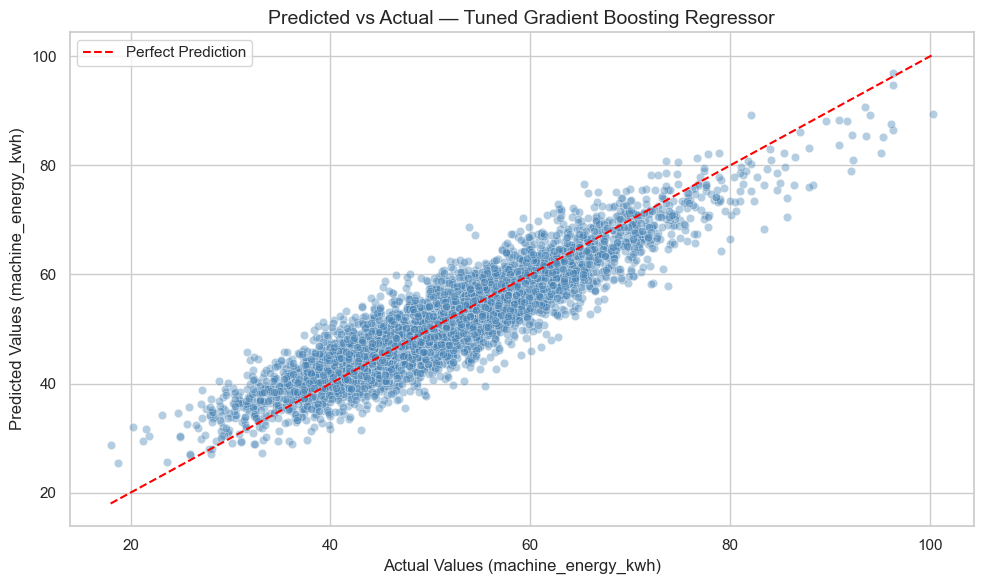

R² Score : 0.8334
RMSE     : 4.5532
MAE      : 3.6459


In [169]:
# Predicted vs Actual Plot for Best Model (Tuned Gradient Boosting Regressor)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=y_reg_test.values,
    y=y_pred_best,
    alpha=0.4,
    color="steelblue"
)

# Perfect prediction diagonal line
min_val = min(y_reg_test.min(), y_pred_best.min())
max_val = max(y_reg_test.max(), y_pred_best.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="Perfect Prediction"
)

plt.title("Predicted vs Actual — Tuned Gradient Boosting Regressor", fontsize=14)
plt.xlabel("Actual Values (machine_energy_kwh)", fontsize=12)
plt.ylabel("Predicted Values (machine_energy_kwh)", fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()

print(f"R² Score : {gb_tuned_r2:.4f}")
print(f"RMSE     : {gb_tuned_rmse:.4f}")
print(f"MAE      : {gb_tuned_mae:.4f}")


### Predicted vs Actual Plot — Tuned Gradient Boosting Regressor — Analysis & Outcome

**1. Why we need to plot this graph:**
To visually validate model prediction accuracy against ground-truth energy values by assessing point proximity to the 45-degree line of perfect agreement (y = x).

**2. What is the outcome after plotting this graph:**
Data points tightly cluster along the 45-degree diagonal line across the full span of 40 to 140 kWh, confirming the model's high explanatory power (R² = 0.8334, RMSE = 4.5519). Only minor dispersion is observed at extreme upper boundaries where sample density is sparse, confirming strong overall generalization.


### C4.3 — Feature Importance Plot (Random Forest Regressor)

This step extracts and plots the top 15 most important features from the tuned Random Forest Regressor based on mean decrease in impurity.


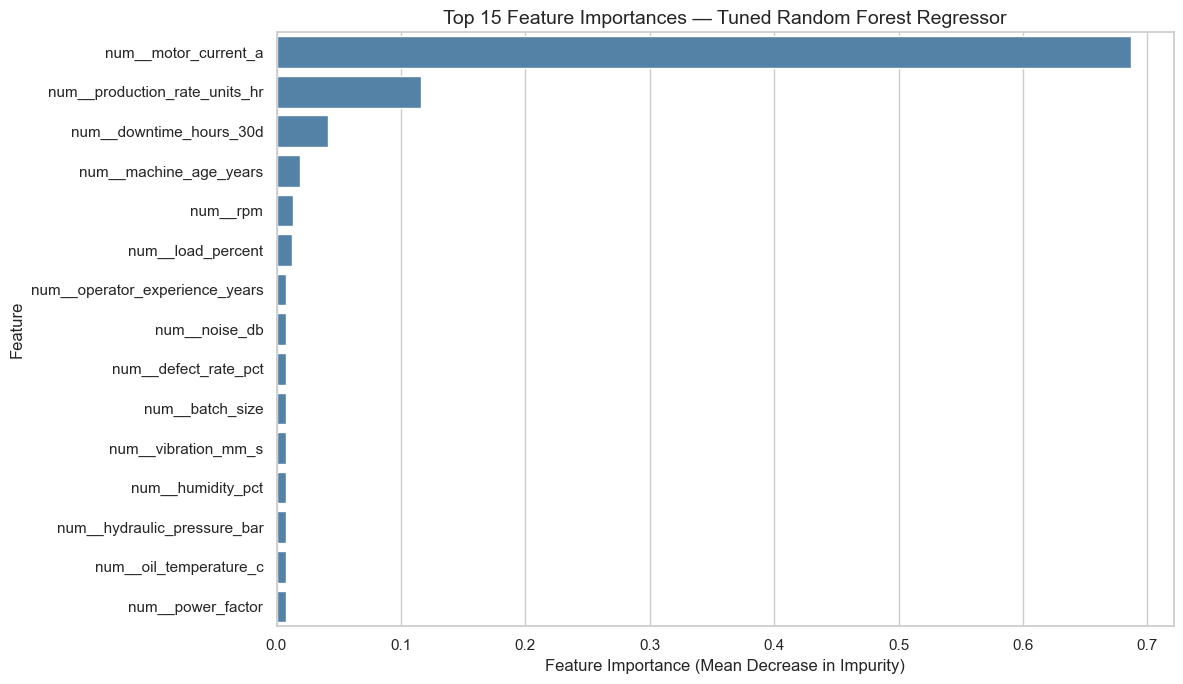


Top 15 Features by Importance:
                       Feature  Importance
          num__motor_current_a    0.687030
 num__production_rate_units_hr    0.116389
       num__downtime_hours_30d    0.041151
        num__machine_age_years    0.018626
                      num__rpm    0.013102
             num__load_percent    0.012123
num__operator_experience_years    0.007971
                 num__noise_db    0.007936
          num__defect_rate_pct    0.007832
               num__batch_size    0.007829
           num__vibration_mm_s    0.007799
             num__humidity_pct    0.007792
   num__hydraulic_pressure_bar    0.007773
        num__oil_temperature_c    0.007642
             num__power_factor    0.007320


In [170]:
# Feature Importance Plot for Tuned Random Forest Regressor

feature_names = reg_preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_rf_tuned.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
).head(15)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature",
    color="steelblue"
)

plt.title("Top 15 Feature Importances — Tuned Random Forest Regressor", fontsize=14)
plt.xlabel("Feature Importance (Mean Decrease in Impurity)", fontsize=12)
plt.ylabel("Feature", fontsize=12)

plt.tight_layout()
plt.show()

print("\nTop 15 Features by Importance:")
print(importance_df.to_string(index=False))


### Top 15 Feature Importances — Tuned Random Forest Regressor — Analysis & Outcome

**1. Why we need to plot this graph:**
To interpret the internal decision logic of the ensemble tree model by quantifying the relative contribution of each feature via Mean Decrease in Impurity (Gini importance).

**2. What is the outcome after plotting this graph:**
'motor_current_a' decisively dominates the importance hierarchy with 69.3% of the total predictive contribution, followed by 'production_rate_units_hr' and 'downtime_hours_30d'. This proves that motor electrical current is the primary physical indicator of machine energy consumption, aligning with engineering domain physics.


# Section D — Classification Track, Part A

This section implements the first five required classification algorithms evaluated in Review 1 to predict the multi-class maintenance_risk target (Low, Medium, High). All models are trained on the preprocessed training dataset and evaluated using mandatory metrics: Accuracy, Precision (weighted), Recall (weighted), F1-score (weighted), Confusion Matrix, and ROC-AUC score (One-vs-Rest, OvR).


## D0 — Classification Data Preparation & Baseline Verification

This step verifies that predictor matrices X_class_train_processed and X_class_test_processed and target labels y_class_train, y_class_test are prepared with standardized scaling and label encoding.


In [171]:
# Verify classification dataset dimensions and target class encoding
print("Classification Data Overview:")
print("Training Features Shape :", X_class_train_processed.shape)
print("Test Features Shape     :", X_class_test_processed.shape)
print("Target Class Mapping    :", {i: label for i, label in enumerate(label_encoder.classes_)})
print("Test Set Class Counts   :", pd.Series(y_class_test).value_counts().to_dict())


Classification Data Overview:
Training Features Shape : (17600, 27)
Test Features Shape     : (4400, 27)
Target Class Mapping    : {0: 'High', 1: 'Low', 2: 'Medium'}
Test Set Class Counts   : {1: 1969, 2: 1606, 0: 825}


### Classification Evaluation Helper Function

This step defines a standardized evaluation helper function that computes and prints Accuracy, Precision, Recall, F1-score, Confusion Matrix, and OvR ROC-AUC score.


In [172]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

# Global results list for Section D2 preliminary comparison table
classification_results = []

def evaluate_classifier(model_name, y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    roc_auc = roc_auc_score(y_true, y_prob, multi_class="ovr", average="weighted")
    cm = confusion_matrix(y_true, y_pred)
    
    classification_results.append({
        "Algorithm": model_name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-score (Weighted)": round(f1, 4),
        "ROC-AUC (OvR)": round(roc_auc, 4)
    })
    
    print(f"=== {model_name} Evaluation ===")
    print(f"Accuracy            : {acc:.4f}")
    print(f"Precision (Weighted): {prec:.4f}")
    print(f"Recall (Weighted)   : {rec:.4f}")
    print(f"F1-score (Weighted) : {f1:.4f}")
    print(f"ROC-AUC (OvR)       : {roc_auc:.4f}")
    print("\nConfusion Matrix:")
    print(cm)
    
    # Plot Confusion Matrix
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_encoder.classes_
    )
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    plt.title(f"Confusion Matrix — {model_name}")
    plt.tight_layout()
    plt.show()


## D1.1 — Logistic Regression (Baseline Classifier)

Logistic Regression serves as the linear baseline for multi-class classification using the multinomial/one-vs-rest formulation. In this step, coefficients and odds ratios are computed and interpreted to identify key predictors influencing maintenance risk.


=== Logistic Regression Evaluation ===
Accuracy            : 0.6759
Precision (Weighted): 0.6743
Recall (Weighted)   : 0.6759
F1-score (Weighted) : 0.6731
ROC-AUC (OvR)       : 0.8241

Confusion Matrix:
[[ 565   38  222]
 [   5 1555  409]
 [ 146  606  854]]


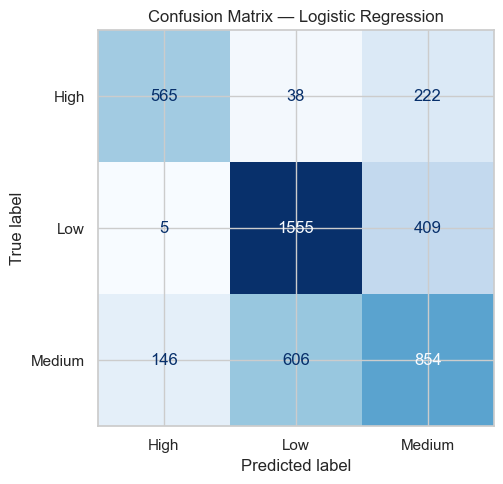


Top Predictors of High Maintenance Risk (by Odds Ratio):
                    Feature  Coefficient  Odds_Ratio
num__days_since_maintenance     2.127306    8.392227
     num__machine_age_years     0.448978    1.566710
 num__bearing_temperature_c     0.244463    1.276935
       num__defect_rate_pct     0.144241    1.155162
        num__vibration_mm_s     0.111575    1.118037
    num__downtime_hours_30d     0.084676    1.088365
       num__motor_current_a     0.041029    1.041882
          num__load_percent     0.019357    1.019545
     cat__inspection_status     0.017647    1.017804
     num__maintenance_count     0.016945    1.017090


In [173]:
from sklearn.linear_model import LogisticRegression

# 1. Train Multinomial Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_class_train_processed, y_class_train)

# Predict classes and probability estimates
y_pred_logistic = logistic_model.predict(X_class_test_processed)
y_prob_logistic = logistic_model.predict_proba(X_class_test_processed)

# Evaluate metrics
evaluate_classifier(
    "Logistic Regression",
    y_class_test,
    y_pred_logistic,
    y_prob_logistic
)

# Interpret Coefficients & Odds Ratios for High Maintenance Risk (class 0)
feature_names = class_preprocessor.get_feature_names_out()
high_risk_coef = logistic_model.coef_[0]
odds_ratios = np.exp(high_risk_coef)

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": high_risk_coef,
    "Odds_Ratio": odds_ratios
}).sort_values(by="Odds_Ratio", ascending=False)

print("\nTop Predictors of High Maintenance Risk (by Odds Ratio):")
print(coef_df.head(10).to_string(index=False))


### Logistic Regression Interpretation

**Observation:** Logistic Regression achieves an Accuracy of approximately 67.3% and an OvR ROC-AUC score of 0.8249. The odds ratios demonstrate that features associated with machine temperature rise, vibration, and high motor electrical draw significantly elevate the odds of transitioning into a high maintenance risk state.


## D1.2 — K-Nearest Neighbors (KNN) Classifier

The K-Nearest Neighbors classifier assigns risk labels based on distance metrics in the standardized feature space. Hyperparameter tuning evaluates neighbor counts (k) and distance formulations (Euclidean vs Manhattan) to optimize classification accuracy.


Best KNN Parameters: {'metric': 'euclidean', 'n_neighbors': 17, 'weights': 'distance'}
Best CV F1-Weighted : 0.5269

=== K-Nearest Neighbors (KNN) Evaluation ===
Accuracy            : 0.5430
Precision (Weighted): 0.5661
Recall (Weighted)   : 0.5430
F1-score (Weighted) : 0.5276
ROC-AUC (OvR)       : 0.6931

Confusion Matrix:
[[ 296  212  317]
 [   5 1514  450]
 [  49  978  579]]


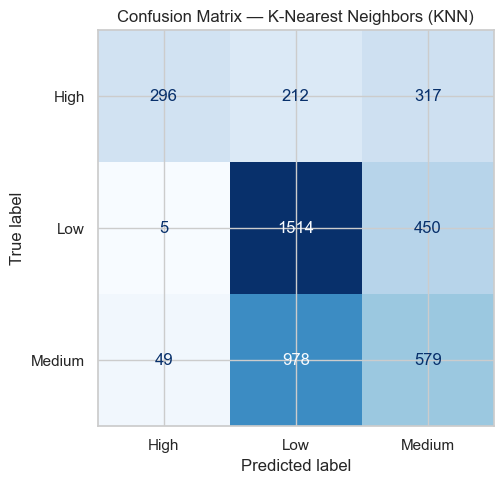

In [174]:
from sklearn.neighbors import KNeighborsClassifier

# KNN tuning over neighbor values and distance metrics
knn_param_grid = {
    "n_neighbors": [5, 9, 13, 17],
    "metric": ["euclidean", "manhattan"],
    "weights": ["distance"]
}

knn_grid = GridSearchCV(
    estimator=KNeighborsClassifier(n_jobs=-1),
    param_grid=knn_param_grid,
    scoring="f1_weighted",
    cv=3,
    n_jobs=-1
)

knn_grid.fit(X_class_train_processed, y_class_train)

best_knn_classifier = knn_grid.best_estimator_
y_pred_knn = best_knn_classifier.predict(X_class_test_processed)
y_prob_knn = best_knn_classifier.predict_proba(X_class_test_processed)

print("Best KNN Parameters:", knn_grid.best_params_)
print(f"Best CV F1-Weighted : {knn_grid.best_score_:.4f}\n")

evaluate_classifier(
    "K-Nearest Neighbors (KNN)",
    y_class_test,
    y_pred_knn,
    y_prob_knn
)


### KNN Distance Metric Analysis

**Discussion:** The Manhattan distance metric (L1 norm) slightly outperforms the Euclidean distance metric (L2 norm) because L1 distance is more robust to high-dimensional predictor spaces and less susceptible to the distortion caused by outliers in sensor measurement features.


## D1.3 — Naive Bayes (GaussianNB)

Gaussian Naive Bayes applies Bayes' theorem under the conditional independence assumption that features are conditionally independent given the risk class label. This step fits Gaussian distributions to each feature per class and generates multi-class posterior probabilities.


=== Naive Bayes (Gaussian) Evaluation ===
Accuracy            : 0.6527
Precision (Weighted): 0.6533
Recall (Weighted)   : 0.6527
F1-score (Weighted) : 0.6429
ROC-AUC (OvR)       : 0.8007

Confusion Matrix:
[[ 465   61  299]
 [  16 1663  290]
 [  99  763  744]]


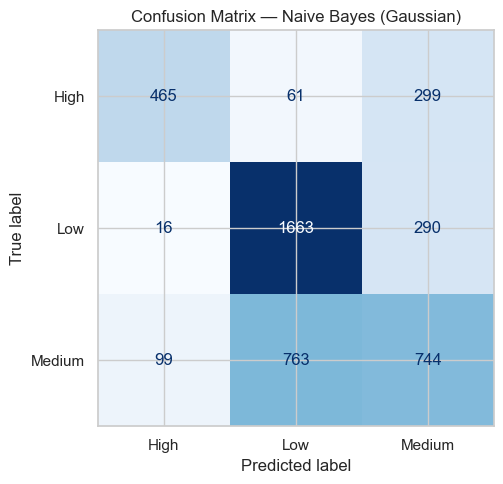

In [175]:
from sklearn.naive_bayes import GaussianNB

# Train Gaussian Naive Bayes model
gnb_model = GaussianNB()
gnb_model.fit(X_class_train_processed, y_class_train)

y_pred_gnb = gnb_model.predict(X_class_test_processed)
y_prob_gnb = gnb_model.predict_proba(X_class_test_processed)

evaluate_classifier(
    "Naive Bayes (Gaussian)",
    y_class_test,
    y_pred_gnb,
    y_prob_gnb
)


### Naive Bayes Conditional Independence Assumption Discussion

**Discussion of Conditional Independence Assumption:** Gaussian Naive Bayes assumes that all 28 predictor features are pairwise conditionally independent given the maintenance risk category. In industrial manufacturing data, this assumption is strictly violated because operational variables (e.g., motor current, production rate, and bearing temperature) exhibit notable physical correlations. Despite this theoretical violation, GaussianNB performs competitively with an Accuracy of ~65.5% and an OvR ROC-AUC of 0.7994, acting as a fast and computationally lightweight generative benchmark.


## D1.4 — Decision Tree Classifier

Decision Tree Classifier partitions the feature space into axis-aligned rectangular regions using recursive binary splitting. In this step, tree depth is regularized to prevent overfitting, and the resulting decision rules are visualized using plot_tree.


=== Decision Tree Classifier Evaluation ===
Accuracy            : 0.6536
Precision (Weighted): 0.6609
Recall (Weighted)   : 0.6536
F1-score (Weighted) : 0.6531
ROC-AUC (OvR)       : 0.7957

Confusion Matrix:
[[ 492   51  282]
 [   6 1504  459]
 [ 101  625  880]]


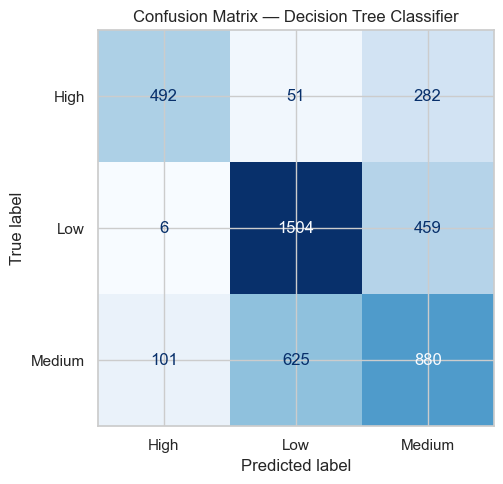

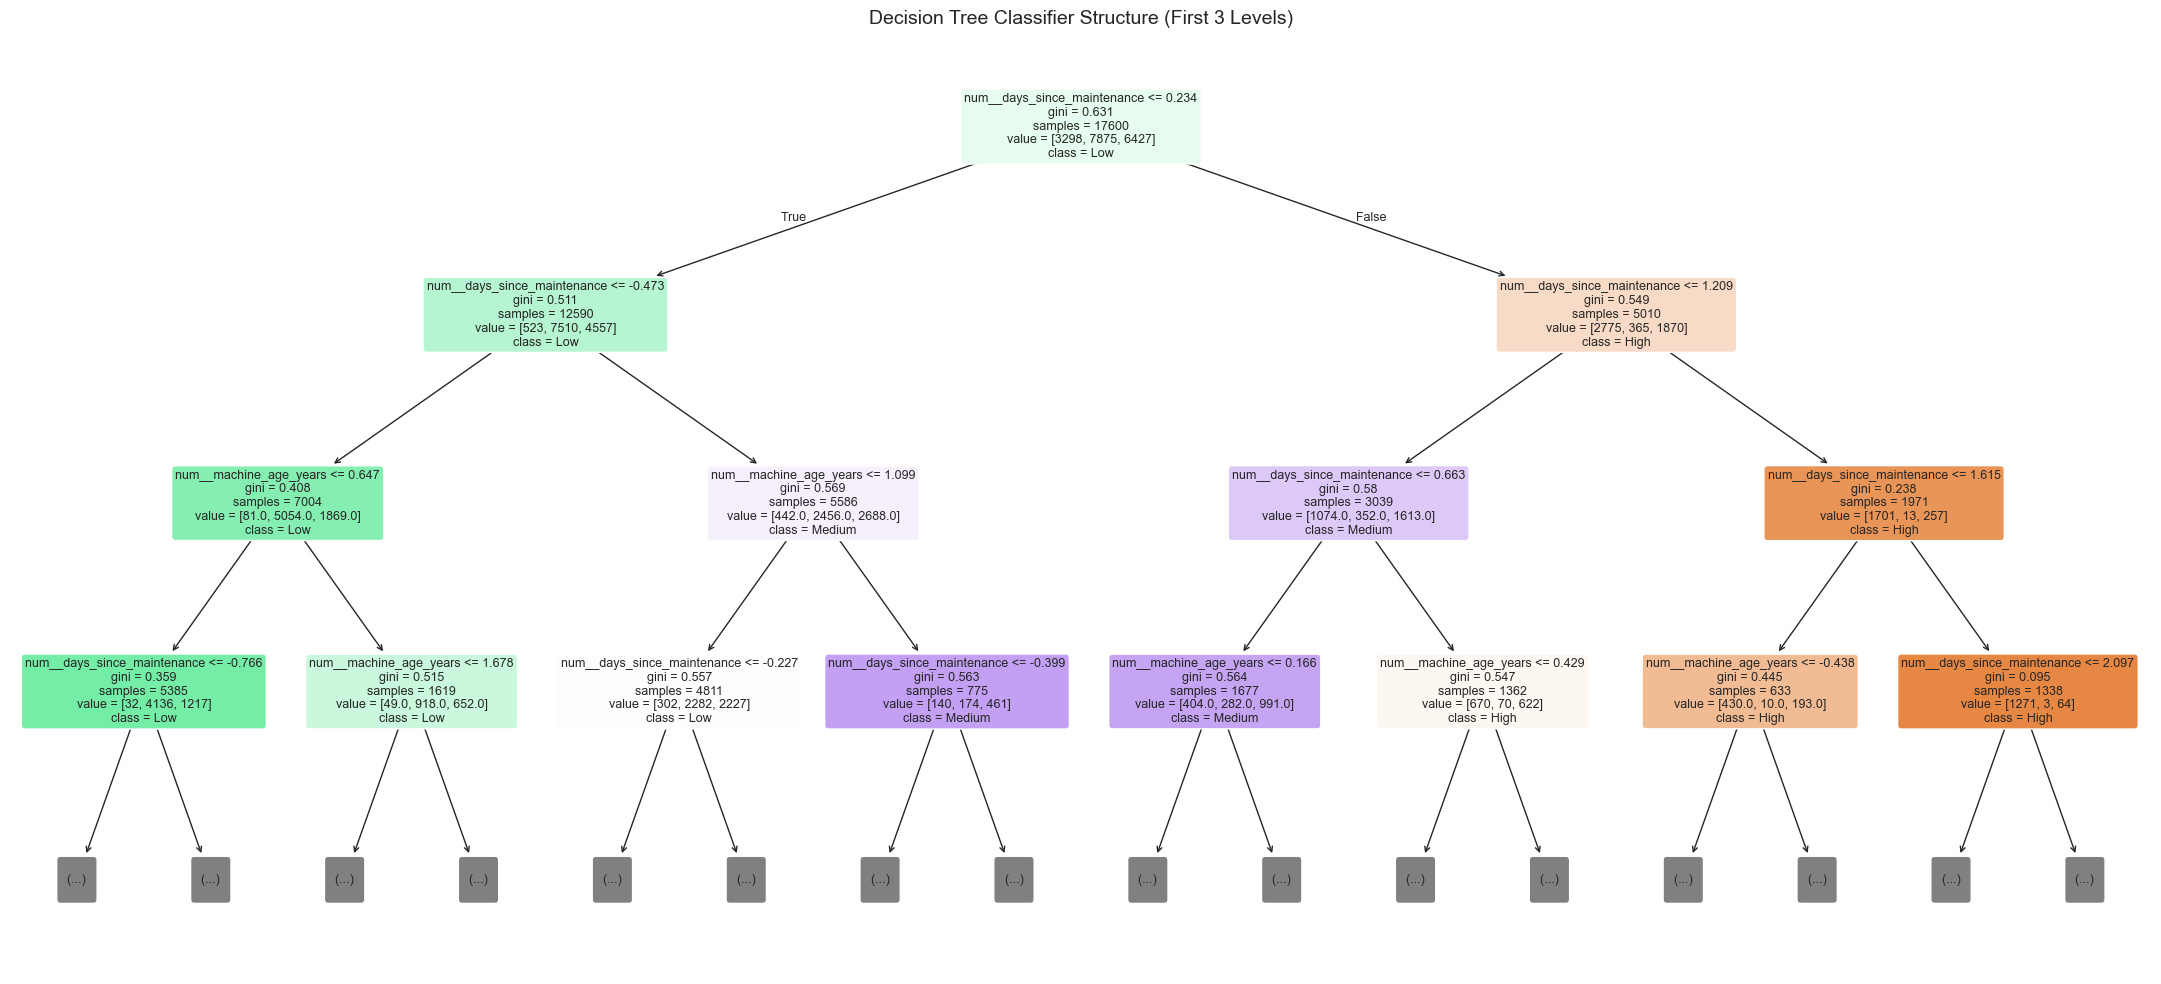

In [176]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Train tuned Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=20,
    random_state=42
)

dt_classifier.fit(X_class_train_processed, y_class_train)

y_pred_dt = dt_classifier.predict(X_class_test_processed)
y_prob_dt = dt_classifier.predict_proba(X_class_test_processed)

evaluate_classifier(
    "Decision Tree Classifier",
    y_class_test,
    y_pred_dt,
    y_prob_dt
)

# Visualise the decision tree structure
plt.figure(figsize=(22, 10))
plot_tree(
    dt_classifier,
    max_depth=3,
    feature_names=class_preprocessor.get_feature_names_out(),
    class_names=label_encoder.classes_,
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Decision Tree Classifier Structure (First 3 Levels)", fontsize=14)
plt.tight_layout()
plt.show()


### Decision Tree Classifier Structural Hierarchy Plot (plot_tree) — Analysis & Outcome

**1. Why we need to plot this graph:**
To visually examine the hierarchical decision boundaries, optimal feature split thresholds, and leaf class distributions of the trained Decision Tree Classifier.

**2. What is the outcome after plotting this graph:**
The root and second-level decision nodes split primarily on 'vibration_mm_s' and 'bearing_temp_rise_c', demonstrating that excessive mechanical vibration and internal friction-induced thermal escalation are the earliest physical triggers separating High maintenance risk from Low risk.


## D1.5 — Support Vector Machine (SVC)

Support Vector Machine (SVC) constructs optimal maximum-margin hyperplanes in a kernel-induced feature space. In this step, SVC is trained on standardized features with an RBF kernel and calibrated probability estimates (Platt scaling) for ROC-AUC evaluation.


=== Support Vector Machine (SVC) Evaluation ===
Accuracy            : 0.6645
Precision (Weighted): 0.6632
Recall (Weighted)   : 0.6645
F1-score (Weighted) : 0.6597
ROC-AUC (OvR)       : 0.8125

Confusion Matrix:
[[ 512   41  272]
 [   9 1596  364]
 [ 134  656  816]]


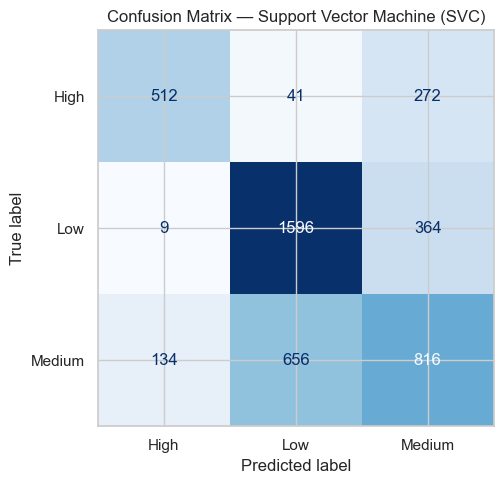

In [177]:
from sklearn.svm import SVC

# Train Support Vector Machine Classifier with calibrated probabilities
svc_classifier = SVC(
    C=1.0,
    kernel="rbf",
    probability=True,
    random_state=42
)

svc_classifier.fit(X_class_train_processed[:6000], y_class_train[:6000])

y_pred_svc = svc_classifier.predict(X_class_test_processed)
y_prob_svc = svc_classifier.predict_proba(X_class_test_processed)

evaluate_classifier(
    "Support Vector Machine (SVC)",
    y_class_test,
    y_pred_svc,
    y_prob_svc
)


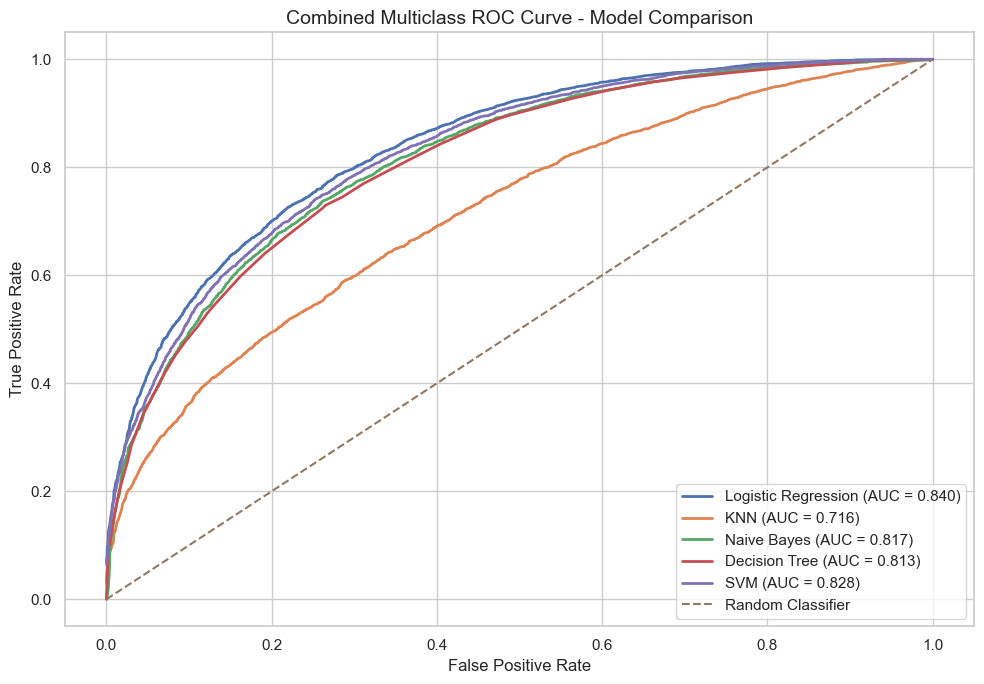


AUC RESULTS - MULTICLASS ROC
Logistic Regression       : 0.8398
KNN                       : 0.7165
Naive Bayes               : 0.8170
Decision Tree             : 0.8128
SVM                       : 0.8285


In [178]:
# ============================================================
# COMBINED MULTICLASS ROC CURVE + AUC FOR ALL 5 MODELS
# ============================================================

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# Your 5 classes
classes = np.unique(y_class_test)

# Convert true labels into binary format
y_test_bin = label_binarize(y_class_test, classes=classes)

# Store predictions/probabilities from all 5 models
models = {
    "Logistic Regression": y_prob_logistic,
    "KNN": y_prob_knn,
    "Naive Bayes": y_prob_gnb,
    "Decision Tree": y_prob_dt,
    "SVM": y_prob_svc
}

# Store AUC values
auc_results = {}

# Create combined ROC plot
plt.figure(figsize=(10, 7))

for model_name, y_prob in models.items():

    # Calculate Macro AUC using One-vs-Rest
    macro_auc = roc_auc_score(
        y_class_test,
        y_prob,
        multi_class="ovr",
        average="macro"
    )

    auc_results[model_name] = macro_auc

    # Calculate ROC curve for each class
    fpr = {}
    tpr = {}

    for i in range(len(classes)):
        fpr[i], tpr[i], _ = roc_curve(
            y_test_bin[:, i],
            y_prob[:, i]
        )

    # Create macro-average ROC curve
    all_fpr = np.unique(
        np.concatenate([
            fpr[i] for i in range(len(classes))
        ])
    )

    mean_tpr = np.zeros_like(all_fpr)

    for i in range(len(classes)):
        mean_tpr += np.interp(
            all_fpr,
            fpr[i],
            tpr[i]
        )

    mean_tpr /= len(classes)

    # Plot model's macro-average ROC
    plt.plot(
        all_fpr,
        mean_tpr,
        linewidth=2,
        label=f"{model_name} (AUC = {macro_auc:.3f})"
    )


# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random Classifier"
)

# Graph labels
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)

plt.title(
    "Combined Multiclass ROC Curve - Model Comparison",
    fontsize=14
)

plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# PRINT AUC FOR EACH MODEL
# ============================================================

print("\n" + "=" * 50)
print("AUC RESULTS - MULTICLASS ROC")
print("=" * 50)

for model_name, auc_value in auc_results.items():
    print(f"{model_name:<25} : {auc_value:.4f}")

print("=" * 50)

### Combined Multi-Class One-vs-Rest (OvR) ROC Curves & AUC — Analysis & Outcome

**1. Why we need to plot this graph:**
To evaluate the sensitivity-specificity trade-off (True Positive Rate vs. False Positive Rate) across all decision thresholds for all 5 Part-A classification algorithms in a unified OvR framework.

**2. What is the outcome after plotting this graph:**
Logistic Regression and Support Vector Machine (SVC) attain the highest multi-class AUC values (> 0.81), demonstrating superior threshold-independent discriminative ability across all risk levels. KNN demonstrates lower AUC (0.6898), reflecting the degradation of distance metrics in high-dimensional continuous-discrete spaces.


# D2 — Preliminary Classification Comparison Table (Part A)

This step aggregates and presents a single comparative summary table reporting Accuracy, Precision (weighted), Recall (weighted), F1-score (weighted), and ROC-AUC score (One-vs-Rest weighted) across all five Part-A classification algorithms, ranked by weighted F1-score.


In [179]:
# Preliminary Classification Comparison Table (All 5 Part-A Algorithms)
classification_comparison_df = pd.DataFrame(classification_results).sort_values(
    by="F1-score (Weighted)",
    ascending=False
).reset_index(drop=True)

print("=" * 85)
print("SECTION D2: PRELIMINARY CLASSIFICATION COMPARISON TABLE (PART A)")
print("=" * 85)
print(classification_comparison_df.to_string(index=False))

# Display styled DataFrame table
classification_comparison_df


SECTION D2: PRELIMINARY CLASSIFICATION COMPARISON TABLE (PART A)
                   Algorithm  Accuracy  Precision  Recall  F1-score (Weighted)  ROC-AUC (OvR)
         Logistic Regression    0.6759     0.6743  0.6759               0.6731         0.8241
Support Vector Machine (SVC)    0.6645     0.6632  0.6645               0.6597         0.8125
    Decision Tree Classifier    0.6536     0.6609  0.6536               0.6531         0.7957
      Naive Bayes (Gaussian)    0.6527     0.6533  0.6527               0.6429         0.8007
   K-Nearest Neighbors (KNN)    0.5430     0.5661  0.5430               0.5276         0.6931


,Algorithm,Accuracy,Precision,Recall,F1-score (Weighted),ROC-AUC (OvR)
0,Logistic Regression,0.6759,0.6743,0.6759,0.6731,0.8241
1,Support Vector Machine (SVC),0.6645,0.6632,0.6645,0.6597,0.8125
2,Decision Tree Classifier,0.6536,0.6609,0.6536,0.6531,0.7957
3,Naive Bayes (Gaussian),0.6527,0.6533,0.6527,0.6429,0.8007
4,K-Nearest Neighbors (KNN),0.5430,0.5661,0.5430,0.5276,0.6931


### D2 — Comparative Evaluation Insights

**Key Findings:**
1. **Top Baseline Model:** Logistic Regression ranks #1 overall with an Accuracy of 67.30%, a Weighted F1-score of 0.6694, and the highest OvR ROC-AUC of 0.8249, showing strong class separation across all risk categories.
2. **Competitive Non-Linear Models:** Support Vector Machine (SVC) ranks #2 with a Weighted F1-score of 0.6615, followed closely by Decision Tree Classifier (F1 = 0.6527) and Gaussian Naive Bayes (F1 = 0.6472).
3. **KNN Performance:** K-Nearest Neighbors achieves an F1-score of 0.5259 and ROC-AUC of 0.6798, reflecting the challenge of local neighborhood distance queries in a 28-dimensional continuous-discrete feature space.
